# Import Statements (libraries + Functions)

In [1]:
import scipy.stats as stats


In [552]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import scipy.stats
import scipy.stats as stats

%matplotlib inline

In [553]:
import ast

In [554]:
import screed
import mmh3

In [555]:
from Bio import SeqIO


In [556]:
import json

In [557]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

In [558]:
import subprocess

In [559]:
from pycirclize import Circos


In [560]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


In [561]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

In [562]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [563]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [564]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import custom utils functions

In [565]:
%load_ext autoreload
%autoreload 2
    
from gcutils.general import Rv_dist, compute_Paralog_EdgeToEdge_Distance

from gcutils.eventtoparalogcomparison import genViz_RecombEvent_Vs_Paralogs_V3
from gcutils.eventtoparalogcomparison import process_and_visualize_event

# from gcutils.homologymapfuncs import label_HmMap_PAF_DF_ByOvrLapGenes, label_HmMap_Variants_DF_ByOvrLapGenes



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import functions for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [566]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from gcutils.genomeviz_utils import plot_Anno_WiVariantCalls_2Panel, plot_Anno_with_empty_bottom

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3

from gcutils.genomeviz_utils import plot_variants_for_isolates_simple
from gcutils.genomeviz_utils import plot_paralog_variants_on_ax
from gcutils.genomeviz_utils import plot_genome_annotation_on_ax

from gcutils.genomeviz_utils import overlay_gc_event_highlights_on_variants

from gcutils.genomeviz_utils import viz_region_Tree_Variants_Anno_ParalogVariants, viz_region_Tree_Variants_Anno


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import functions related to phylogeny/tree viz

In [567]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
    
from gcutils.gubbinsfuncs import get_BranchLengths_and_DescendantCounts_FromTree

from gcutils.gubbinsfuncs import annotate_tree_with_lineages, infer_InternalNode_Lineages

from gcutils.treeviz_mpl import mpl_plot_tree

from gcutils.treeviz_ete_utils import subset_tree_by_leaf_ids, subset_ETE_Tree
from gcutils.treeviz_ete_utils import style_ETE3_Tree_ByMtbLineage_V1

from gcutils.treeviz_ete_utils import style_single_node_in_tree
from gcutils.treeviz_ete_utils import subset_ETE_Tree_Style_GCEChildNode 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define Functions

In [568]:
import re
import pandas as pd
import numpy as np

# reuse your existing regex
CS_OP_RE = re.compile(r'([:=*+-])(\d+|[A-Za-z]+)')

def count_substitutions_in_cs(cs: str) -> int:
    """
    Count the number of substitution events (*xy) in a minimap2 cs tag.

    Parameters
    ----------
    cs : str
        A single cs tag string (e.g. ':6-ata:10+gtc:4*at:3').

    Returns
    -------
    int
        Number of substitutions detected in this cs string.
    """
    if cs is None or (isinstance(cs, float) and pd.isna(cs)):
        return 0

    n_sub = 0
    for op, arg in CS_OP_RE.findall(cs):
        if op == '*':
            # arg is two bases: ref, query
            ref_base = arg[0]
            alt_base = arg[1]
            # mirror your variant logic: skip ambiguous Ns
            if ref_base.lower() != "n" and alt_base.lower() != "n":
                n_sub += 1

    return n_sub


In [569]:

def calculate_gc_content_perwindow(genome_seq, df,
                                   start_col = "Target_Start",
                                   end_col   = "Target_End"):
    """
    Compute GC content for each genomic window in the DataFrame.
    
    Parameters:
    - genome (str): The full genome sequence as a string.
    - df (pd.DataFrame): DataFrame containing "Target_Start" and "Target_End" columns.
    
    Returns:
    - pd.DataFrame: Updated DataFrame with a new column "GC_Content".
    """
    gc_contents = []
    
    for _, row in df.iterrows():
        start = int(row[start_col]) - 1  # Convert to 0-based indexing
        end = int(row[end_col])
        
        # Extract sequence from genome string
        subseq = genome_seq[start:end]
        
        # Calculate GC content
        gc_count = subseq.count('G') + subseq.count('C')
        total_bases = len(subseq)
        gc_content = (gc_count / total_bases) * 100 if total_bases > 0 else None
        
        gc_contents.append(gc_content)

    # Add results to DataFrame
    df["GC_Content"] = gc_contents
    df["GC_Content"] = df["GC_Content"].astype(float)

    return df



## ETE3 Settings & Parameters Setup

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [570]:

import ete3 as ETE

from ete3 import Tree

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

In [571]:
Mtb_LinToColor_Dict = {"lineage1": "#DF83AC",
                      "lineage2": "#7098CB",
                      "lineage3": "#815D9F",
                      "lineage4": "#E76956",
                      "lineage5": "#B67548",
                      "lineage6": "#6AB79E",
                      "lineage8": "#E4515B", 
                      "Ancestral": "black",
                      "None": "black",}


In [572]:

ts_vt_NoScale = ETE.TreeStyle()
ts_vt_NoScale.show_leaf_name = False
ts_vt_NoScale.show_branch_length = False
ts_vt_NoScale.show_branch_support = False
ts_vt_NoScale.show_scale = False #True
ts_vt_NoScale.branch_vertical_margin = 2
ts_vt_NoScale.rotation = 90

ts_hz_NoScale = ETE.TreeStyle()
ts_hz_NoScale.show_leaf_name = False
ts_hz_NoScale.show_branch_length = False
ts_hz_NoScale.show_branch_support = False
ts_hz_NoScale.show_scale = False #True
ts_hz_NoScale.branch_vertical_margin = 2
ts_hz_NoScale.rotation = 0

ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
#ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = False #True
ts_ColLin_circ.branch_vertical_margin = 2
#ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout

ts_ColLin_FullCirc = ETE.TreeStyle()
ts_ColLin_FullCirc.mode = "c" # draw tree in circular mode
ts_ColLin_FullCirc.arc_start = -90 #-180 # 0 degrees = 3 o'clock
ts_ColLin_FullCirc.arc_span = 355
ts_ColLin_FullCirc.show_leaf_name = False
ts_ColLin_FullCirc.show_branch_length = False
ts_ColLin_FullCirc.show_branch_support = False
ts_ColLin_FullCirc.show_scale = False #True
ts_ColLin_FullCirc.branch_vertical_margin = 2
# ts_ColLin_FullCirc.rotation = 90


# Define Color Pallete `Mtb-H37Rv` Gene Categories 

In [573]:
all_categories = [ "PE/PPE", "REP13E12_Repeat", "esx", "conserved hypotheticals", "cell wall and cell processes",
                  "insertion seqs and phages",
                  "intermediary metabolism and respiration", "lipid metabolism", "information pathways",
                  "virulence, detoxification, adaptation", "regulatory proteins",
                   "stable RNAs",  "unknown",  ] 

NQ_Colors = ['065275', '029099', '7CCBA1', 'FDDE9C', 'F0746E', 'DC3978', '7C1E6F']


Mtb_GeneCat_ColorDict = { 
    "PE/PPE" : "#57A89D", #"#1ABFAD", 
    "REP13E12_Repeat" : "#D3516D", 
    "esx" : "#5D81AA", 
    "lipid metabolism" : "#6EA4D4",  # Warm brownish-orange
    "conserved hypotheticals" : "#F2B84A", 
    "cell wall and cell processes" : "#7D3E84", 
    "insertion seqs and phages": "#E16843", 
    "intermediary metabolism and respiration" : "#4F7942",  # Deep green
    "information pathways": "#5698C4",  # Soft blue
    "virulence, detoxification, adaptation": "#B0338E",  # Magenta-purple
    "regulatory proteins": "#A42CD6",  # Vivid violet
    "stable RNAs": "#5C5C5C",  # Neutral dark gray
    "unknown": "#999999",  # Lighter gray for unknown
}

Mtb_GeneCat_ColorPallete =  [Mtb_GeneCat_ColorDict[cat] for cat in all_categories] 

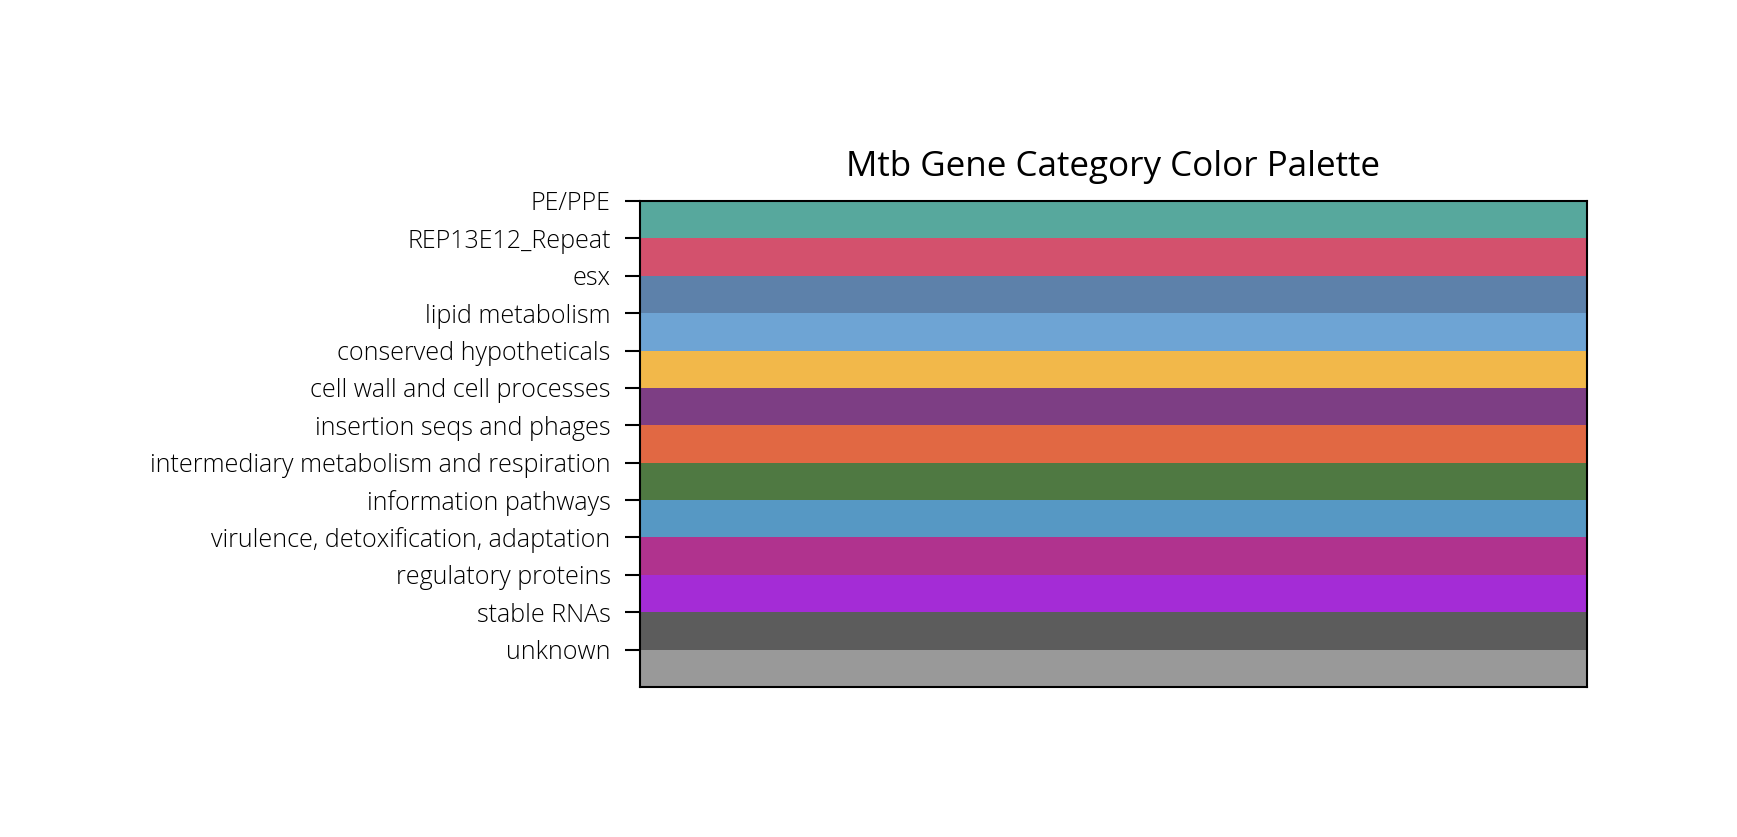

In [574]:
# Plot the colors
fig, ax = plt.subplots(figsize=(5, 2))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(Mtb_GeneCat_ColorDict))
ax.set_xticks([])
ax.set_yticks(range(len(Mtb_GeneCat_ColorDict)))
ax.set_yticklabels(Mtb_GeneCat_ColorDict.keys(), fontsize=6)

for i, (category, color) in enumerate(Mtb_GeneCat_ColorDict.items()):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

plt.gca().invert_yaxis()
plt.title("Mtb Gene Category Color Palette")
plt.show()

# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [575]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [576]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [577]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [578]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)
Mtb_H37rv_Graphic_Record.feature_level_height = 0

1


# Parse `Mtb151CI` Isolate Metadata

In [579]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [580]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [581]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  

SampleID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
SampleID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
SampleID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [582]:
WGA151CI_OrderOfSampleIDs_Phylo = ['N0153', 'N0072', 'mada_2-46', 'mada_1-44', 'mada_107', 'mada_1-1', 'mada_1-51',
                          'mada_1-39', 'mada_1-36', 'mada_117', 'mada_122', 'mada_118', 'mada_1-10', 'R27252',
                          'R23887', 'TB3091', '9050-05', '3003-06', '702-06', '696-05', '8651-04', 'TB3396',
                          '4549-04', 'TB1612', 'TB2780', 'TB3368', 'TB1236', 'TB2659', '8129-04', 'R30215',
                          'R25048', 'TB2512', 'TB2981', 'TB2995', 'TB3113', '706-05', 'R30078', 'R28012',
                          'R27657', 'R30234', 'R31095', 'R28703', 'R24120', 'R36431', 'R29816', 'S0070-08',
                          'N0155', 'N0145', 'R29598', 'R24100', 'S0107-01', 'R28581', 'S0256-08', 'S0085-01',
                          'S0089-01', 'mada_1-11', 'M0003941_3', 'mada_115', 'mada_2-42', 'R37765', '18_0621851',
                          'R22601', 'R27937', 'R18040', 'R18043', 'R27725', 'R26791', 'R20574', 'R20260', 'R21408',
                          'R23146', 'R28980', 'R32929', 'R26778', 'R30420', 'R21893', 'QC-9', 'QC-5', 'QC-3', 'N0004',
                          'mada_1-30', 'N0054', 'N1274', '01_R1134', 'TB2968', 'mada_1-53', 'mada_2-53', 'mada_1-50',
                          'mada_2-1', 'R23571', 'mada_123', 'mada_1-12', 'mada_1-15', 'mada_128', 'mada_1-38', 'TB3054',
                          'mada_126', 'mada_120', 'TB4620', 'M0016737_0', 'M0016395_7', 'R15311', 'TB2661', 'TB3386',
                          'TB3162', '02_R1179', 'M0010874_7', 'QC-7', 'QC-6', 'QC-1', '01_R1430', 'M0011368_9',
                          '02_R1896', 'mada_2-25', 'TB3237', 'mada_103', 'mada_112', 'mada_124', 'S0123-01', 'S0262-02',
                          'TB3251', 'M0017522_5', 'R30396', 'R20896', 'mada_1-32', 'S0106-01', 'R21839', 'R21363', 'R21770',
                          'MT_0080', 'mada_102', 'TB3334', 'M0014888_3', 'mada_151', 'TB3169', 'mada_105', 'QC-8', 'QC-10',
                          'QC-4', 'mada_129', 'mada_139', '02_R1708', '02_R0894', 'mada_2-31', 'mada_1-41', 'N1272', 'N1176',
                          'N1202', 'N0091', 'N1177', 'RW-TB008']


# Parse all individual variants per genome annotated by CDS effect (`WGA-151CI`)

In [583]:
Mtb151_AllVar_Dir = "../../Data/241030.Mtb151CI.AllVariants.Anno.V1/"

Mtb151_AllVar_TSVGZ              = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.V1.tsv.gz"
Mtb151_AllVar_WiCDSAnno_TSVGZ    = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.WiCDSAnno.V1.tsv.gz"
Mtb151_SNPs_WiInterSNPDist_TSVGZ = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllSNPs.WiInterSNPDists.V1.tsv"


In [584]:

Mtb151CI_AllAsm_AllVar_DF = pd.read_csv(Mtb151_AllVar_WiCDSAnno_TSVGZ, sep="\t")

# WGA151_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF.shape

(260869, 20)

In [585]:
AllAsm_AllVar_DF["SampleID"].nunique()

151

# Parse HHRs tested for Enrichment of "Paralog-Matching" SNPs

In [586]:
HHR_TestForParalogSNPs_TSV = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/Analysis/4_Mtb_HHR_MutAttributes_V3/HHR.TestedForParalogSNPS.V1.tsv"

HHR_SNP_Sig_DF  = pd.read_csv(HHR_TestForParalogSNPs_TSV,
                              sep = "\t")

HHR_SNP_Sig_DF["Num_Overlap_Genes"] = HHR_SNP_Sig_DF["Overlap_Genes"].str.split(",").apply(len)

HHR_SNP_Sig_DF.shape

(61, 31)

In [587]:
HHR_SNP_Sig_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Num_Overlap_Genes
0,165,NC_000962.3,3710379,3712822,3711600.5,2443,"Rv3325,Rv3326,Rv3327",3,15,1,0,165,PR_HmRegion_165,1,7329,1,17,4,0.0,500.0,500.0,0.002320,1.000000e-40,500.0,0,1724.470588,3.236656,10.751938,3.997680,0.018605,3
1,25,NC_000962.3,606510,608060,607285.0,1550,"Rv0515,Rv0516c",0,1,1,0,25,PR_HmRegion_025,0,4650,1,10,3,0.0,500.0,500.0,0.002151,1.000000e-40,500.0,0,1395.000000,3.144574,10.446049,2.997849,0.013953,2
2,44,NC_000962.3,1169296,1170733,1170014.5,1437,Rv1047,1,5,3,0,44,PR_HmRegion_044,0,4311,2,34,16,0.0,500.0,500.0,0.015774,1.000000e-40,500.0,0,1014.352941,3.006189,9.986344,15.984226,0.074419,1
3,15,NC_000962.3,400151,401701,400926.0,1550,Rv0336,0,1,1,0,15,PR_HmRegion_015,0,4650,1,14,3,0.0,500.0,500.0,0.003011,1.000000e-40,500.0,0,996.428571,2.998446,9.960623,2.996989,0.013953,1
4,158,NC_000962.3,3481324,3482760,3482042.0,1436,Rv3115,1,5,3,0,158,PR_HmRegion_158,0,4308,2,64,29,0.0,500.0,500.0,0.029712,1.000000e-40,500.0,0,976.031250,2.989464,9.930784,28.970288,0.134884,1


# Import/parse processed H37rv genome annotations

In [588]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
#H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [589]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways


### Define paths to H37Rv genome masking schemes

In [590]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [591]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [592]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [593]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Parse H37Rv Reference sequences (Genome, Genes, Proteins)

## Parse H37Rv genome sequence (DNA)

In [594]:
from Bio import SeqIO


In [595]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"
H37Rv_FA = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.fasta"

H37Rv_Seq = SeqIO.read(H37Rv_FA, "fasta").seq
len(H37Rv_Seq)

4411532

## Parse H37Rv Protein (AA) and gene (DNA) sequences

In [596]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

MycoBrowser_RefFiles_Dir = f"{O2_RefDir}/190619_Mycobrowser_H37rv_ReferenceFiles"

H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta"
H37Rv_Proteins_NCBI_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37RV_Genes_FA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta"



H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.faa"
H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.esxM_Added.faa"
H37Rv_GBK_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"


In [597]:
!ls -1 $MycoBrowser_RefFiles_Dir

Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta.fai
Mycobacterium_tuberculosis_H37Rv_gff_v3.gff
Mycobacterium_tuberculosis_H37Rv_gff_v3.REP13E12_Regions.gff
Mycobacterium_tuberculosis_H37Rv_proteins_v3.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta
Mycobacterium_tuberculosis_H37Rv_txt_v3_PEPPE_subfamilies.txt
Mycobacterium_tuberculosis_H37Rv_txt_v3.txt.tsv


### Parse MycoBrowser Protein Seq Ref

In [598]:
dictOf_H37Rv_MycoBrow_ProtSeq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_Proteins_MycoBro_FAA, "fasta"))):
    ShortID = record.name
    
    dictOf_H37Rv_MycoBrow_ProtSeq[ShortID] = record.seq


4091it [00:00, 174832.11it/s]


### Parse MycoBrowser Gene Seq Ref

In [599]:
dictOf_H37Rv_MycoBrow_Gene_Seq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37RV_Genes_FA, "fasta"))):

    ShortID = record.name.split("|")[0]
    dictOf_H37Rv_MycoBrow_Gene_Seq[ShortID] = record.seq


4187it [00:00, 112730.86it/s]


In [600]:
list(dictOf_H37Rv_MycoBrow_Gene_Seq.keys())[:2]

['Rv3728', 'Rv3729']

### Parse NCBI Protein Seq Ref

In [601]:
dictOf_H37Rv_ProtSeq = {}
dictOf_H37Rv_ProtRecord = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_FAA_PATH, "fasta"))):
    Rec_Description = record.description
    dict_Attr = {}
    for i in Rec_Description.split(" "):
        ###Just looking for line with " " character (as key = value)
        if "=" in i:
            key = i.strip().split("=")[0].strip('"').strip('[')
            value = i.strip().split("=")[1].strip('"').strip(']')
            ###Put them in a dictionnary
            dict_Attr[key]=value
    
    ShortID = dict_Attr["locus_tag"]
    dictOf_H37Rv_ProtSeq[ShortID] = record.seq
    dictOf_H37Rv_ProtRecord[ShortID] = record


3907it [00:00, 93497.65it/s]


In [602]:
#dictOf_H37Rv_ProtSeq["Rv1196"]

In [603]:
#dictOf_H37Rv_ProtSeq["Rv1196"] == dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [604]:
dictOf_H37Rv_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

In [605]:
dictOf_H37Rv_MycoBrow_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [606]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"



### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [607]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                           sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [608]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                               sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [609]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [610]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [611]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [612]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [613]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [614]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

### Parse in HomologyMap Alignment Variants DFs

In [615]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [616]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [617]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


In [618]:
Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.head(3)

,Target_Name,Target_Start,Target_End,Ref,Alt,SNP
0,NC_000962.3,3082657,3082658,T,C,True
1,NC_000962.3,3082660,3082661,C,A,True
2,NC_000962.3,3082667,3082668,G,A,True


In [619]:
# Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
# Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

# print(Mtb_HM_Var_DF.shape)
# print(Mtb_HM_Var_SNPs_DF.shape)

In [620]:
Mtb_HM_Var_PR_SNPs_DF.head(5)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082671,3082672,+,G,A,True,SNP,NC_000962.3,80426,80427,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [621]:
HmMap_Aln_k19w19_NoOverlap_DF.head(5)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


# Parse `Nuc-Div` results for `WGA-151CI` dataset

## Define NucDiv analysis file paths

In [622]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

#NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"
NucDiv_NoFilt_1kb_V2_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv"


### Parse pickle of NucDiv stats

In [623]:
with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [624]:
xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000


### Parse 1-kb NucDiv DF

In [625]:
# Read in TSV
WGA_NucDiv_PI_1kb_DF = pd.read_csv(NucDiv_NoFilt_1kb_V2_TSV_PATH, sep = "\t")

NucDiv_1kb_DF = WGA_NucDiv_PI_1kb_DF

# Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = NucDiv_1kb_DF['NucDiv'].median()
mean_1kb_PI = NucDiv_1kb_DF['NucDiv'].mean()
std_1kb_PI = NucDiv_1kb_DF['NucDiv'].std()
MAD_1kb_PI = np.median(np.abs(NucDiv_1kb_DF['NucDiv'] - median_1kb_PI))


### Define NucDiv Hospots (N = 37)

In [626]:
NucDiv_HSR_1kb_DF = NucDiv_1kb_DF.query("IsNucDivHotspot == True")
NucDiv_HSR_1kb_DF.shape

(37, 20)

In [627]:
NucDiv_HSR_1kb_DF.head(5)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1
1095,NC_000962.3,1095000,1096000,0.003100,"rpmF,PE_PGRS18",1095500.0,3.10016,4.893546,14.180072,True,2,1,0,0,1,1,3,1,1,1


#### Extra Inspection of NucDiv DFs

In [628]:
NucDiv_1kb_DF.head(2)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0


In [629]:
NucDiv_1kb_DF["NucDiv_kb"].describe()

count    4421.000000
mean        0.319492
std         0.568232
min         0.000000
25%         0.078678
50%         0.191679
75%         0.405184
max        15.960600
Name: NucDiv_kb, dtype: float64

In [630]:
NucDiv_HSR_1kb_DF.head(4)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1


In [631]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 1").shape

(36, 20)

In [632]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 0").shape

(1, 20)

# Parse `Mtb151-MainAnalysis` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [633]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

i_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = i_Gubbins_V1_OutputDir

i_Gubbins_OutPrefix = "Gubbins"

i_Gubbins_FullPrefix_PATH  = f"{i_Gubbins_V1_OutputDir}/{i_Gubbins_OutPrefix}"

i_Gubbins_FilePath_Dict = {}

i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{i_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{i_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
i_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
i_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
#i_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedParalogRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedLocalRepeatRegion.tsv"

i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{i_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"


######### Add Event to Paralog Mapping Results File Paths ##########
EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

# Parsimony Scores (Fitch) for all mutations associated with each event
GCE_ParsimonyScores_PerEvent_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerEvent.tsv"
GCE_ParsimonyScores_PerSite_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerSite.tsv"

i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"] = GCE_ParsimonyScores_PerEvent_TSV
i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"]  = GCE_ParsimonyScores_PerSite_TSV


####################################################################


## A) Parse table of ALL Gubbins Events (all putative recomb events) - `WGA-151-GCE` 

In [634]:
print( i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]) 

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh/Gubbins.recombination_predictions.Anno.tsv


In [635]:
# Parse annotated events TSV
GRE_DF = pd.read_csv(i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")

# Convert the string column to a list of strings
GRE_DF['taxa_List'] = GRE_DF['taxa_List'].apply(ast.literal_eval)
GRE_DF["LenOfTaxaList"] = GRE_DF["taxa_List"].apply(len)

GRE_DF.shape

(324, 31)

### B) Parse Gubbins recombination events counted over regions (`1 kb window`, `Gene-level`, `HmRegion`)

In [636]:
GCE_CtPerGene_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"], sep = "\t")

GCE_CtPerGene_Atleast1_DF = GCE_CtPerGene_DF.query("pGCE_Count > 0")
GCE_CtPerGene_Atleast1_DF.shape

(76, 15)

In [637]:
GRE_PerPRStats_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"] , sep = "\t")
GRE_PerPRStats_DF.shape

(200, 18)

## C) Parse Gubbins Events - branch-level stats

In [638]:
G_BranchStats_Filt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"], sep = "\t")
G_BranchStats_Filt_DF.shape

(300, 15)

In [639]:
G_BranchStats_Filt_DF.head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
0,N0072,328,36,292,4,391,3619,0.123288,0.013699,4411487,4408943,lineage1,295.04892,0.0,328


In [640]:
G_BranchStats_Filt_DF.query("Lineage == 'lineage4' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
215,Node_65,208,16,192,2,946,1898,0.083333,0.010417,4411532,4409993,lineage4,199.414017,62.0,208


## D) Read in the "node_To_PrimaryLin_Dict" dictionary 

In [641]:
with open(i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

## E) Gubbins ASR SNP DFs

In [642]:
GubSNPs_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"], sep = "\t")
GubSNPs_All_DF.shape

(26508, 13)

In [643]:
GubSNPs_EventOnly_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"], sep = "\t")
GubSNPs_EventOnly_DF.shape

(2916, 13)

In [644]:
GubSNPs_CDSAnno_All_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"], sep = "\t")
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [645]:
GubSNPs_CDSAnno_EventOnly_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"], sep = "\t")
GubSNPs_CDSAnno_EventOnly_V2_DF.shape

(2916, 23)

### Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [646]:
Gub_SNPs_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"],
                                         sep = "\t")
Gub_SNPs_V2_DF.shape

(26508, 23)

In [647]:
#Gub_SNPs_V2_DF.head(1)

In [648]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts() 

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [649]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

## F) Parse `Event-to-Paralog-Mapping` results

### F.1) Event table anno by paralog match

In [650]:
GRE_AnnoByMatch_DF = pd.read_csv(i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"],
                                 sep = "\t")


# Convert the string column to a list of strings
GRE_AnnoByMatch_DF['taxa_List']     = GRE_AnnoByMatch_DF['taxa_List'].apply(ast.literal_eval)
GRE_AnnoByMatch_DF["LenOfTaxaList"] = GRE_AnnoByMatch_DF["taxa_List"].apply(len)


##### Label GC Events by overlap w/ NucDiv Hotspots ######
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")

print(GRE_AnnoByMatch_DF.shape)
GRE_AnnoByMatch_DF = bf.count_overlaps(GRE_AnnoByMatch_DF, NucDiv_HSR_1kb_DF, 
                               cols1 = RE_CoordCols,
                               cols2 = GenomeAnno_CoordCols).rename(columns={'count': 'N_NucDivHotSpots'})
print(GRE_AnnoByMatch_DF.shape)

##########################################################

GRE_ABM_DF = GRE_AnnoByMatch_DF
GRE_ABM_DF.shape

(324, 46)
(324, 47)


(324, 47)

### F.2) Event to all paralogs DF

In [651]:
GRE_MatchToHm_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"],
                               sep = "\t")

GRE_MatchToHm_DF.shape

(590, 15)

### F.3) Event to paralog details dict

In [652]:
with open(i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"], "rb") as f:
    
    dictOf_FullKmerAnalysis_PerEvent = pickle.load(f)
    
print(len(list(dictOf_FullKmerAnalysis_PerEvent.keys()) ))

295


### F.4) HmMap and GCE Stats annotated onto HmRegions and HmMap alignment pairs  
- Parse in mapping results quantified across `Paralogous Regions and each `HmMap-Alignment`

In [653]:
HmPair_EventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"],
                                sep = "\t")

HmPair_EventCt_DF["Aln_N_SNPs"] = HmPair_EventCt_DF["cs"].apply(count_substitutions_in_cs)


HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 100")
HmPair_EventsOnly_DF = HmPair_EventCt_NoPerf_DF.query("EventsMapped > 0")



HmRegions_DonorAndEventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"],
                                           sep = "\t")


In [654]:
HmRegions_DonorAndEventCt_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


In [655]:
HmPair_EventCt_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


## G) Parsimony Scoring of SNPs per GC Event


In [656]:
GCE_FitchQC_PerEvent_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"],
                                      sep = "\t")

GCE_FitchQC_PerSite_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"],
                                      sep = "\t")

print("Parsimony Scores - per GC Event - DF shape:", GCE_FitchQC_PerEvent_DF.shape)
print("Parsimony Scores - per SNP of each GC Event - DF shape:", GCE_FitchQC_PerSite_DF.shape)


Parsimony Scores - per GC Event - DF shape: (324, 11)
Parsimony Scores - per SNP of each GC Event - DF shape: (2916, 10)


# Process Gubbins Tree (`Mtb-151CI`)

## Parse and annotate phylogeny

In [657]:
## 1) Parse Gubbins Tree w/ ETE3

i_Gubbins_T = Tree(i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"],
                   format = 1)


# Root the Mtb-151CI tree on the L8 isolate
i_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
i_Gubbins_T.set_outgroup(i_T_RootPoint)

## 2) Parsing over each node of the tree (ETE3), get ML BRANCH LENGTH and Number of descendents per node
Tree_BranchLen_Dict, Tree_NumDescendants_PerNode_Dict = get_BranchLengths_and_DescendantCounts_FromTree(i_Gubbins_T)

## 3) Label each LEAF within phylogeny by MTBC Lineage + Infer lineage of each internal node of the tree
i_Gubbins_T = annotate_tree_with_lineages(i_Gubbins_T,
                                          SampleID_To_PrimLineage_Dict)

# i_Gubbins_T, Tree_PrimaryLin_PerNode_Dict = infer_InternalNode_Lineages(i_Gubbins_T,
#                                                                         SampleID_To_PrimLineage_Dict)

                          

Number of leaves processed: 151


In [658]:
MTBC_AncestralNode = i_Gubbins_T.search_nodes(name="Node_150")[0]

print(MTBC_AncestralNode.name)

Node_150


# Viz `Mtb-151CI` phylogeny with branches colored by MTBC Lineage

In [659]:
Mtb_151CI_Tree_V1 = style_ETE3_Tree_ByMtbLineage_V1(i_Gubbins_T,
                                                   Mtb_LinToColor_Dict,
                                                   node_To_PrimaryLin_Dict, #Tree_PrimaryLin_PerNode_Dict,
                                                   verbose=False)


### Viz `Mtb151CI` Tree -  w/ ETE3

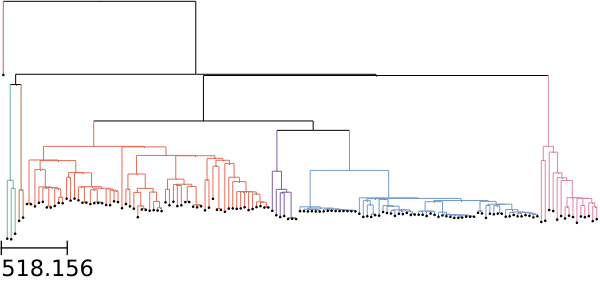

In [660]:
in_Tree = Mtb_151CI_Tree_V1.copy()
in_Tree.render("%%inline", w = 600, tree_style = ts_ColLin)

# Classify & Divide sets of GC Events based on Paralog Mapping results

In [661]:
GCE_All_DF = GRE_AnnoByMatch_DF
GCE_ABM_DF = GRE_AnnoByMatch_DF

# Seperate GC Event Info DF into GCEs WITH and WITHOUT paralogs
GCE_InPR_DF = GCE_All_DF.query("NumHmTargets > 0")
GCE_NotInPR_DF = GCE_All_DF.query("NumHmTargets == 0")

mGCE_DF = GRE_AnnoByMatch_DF.query("MappedEvent == True") #.query("Max_KmerMatch_ToHm > 0.5")
GCE_Mapped_DF = mGCE_DF

GCE_NotMapped_DF = GRE_AnnoByMatch_DF.query("MappedEvent == False") #.query("Max_KmerMatch_ToHm <= 0.5")

GCE_NotMapped_InPR_DF = GCE_NotMapped_DF.query("NumHmTargets > 0")

GCE_NotMapped_NotInPR_DF = GCE_NotMapped_DF.query("NumHmTargets == 0")


print("# of TOTAL detected events", GCE_All_DF.shape[0])

print("# of detected events IN a Paralog-Region:", GCE_InPR_DF.shape[0])
print("# of detected events NOT IN a Paralog-Region:", GCE_NotInPR_DF.shape[0])
print("")
print("# of mapped events", GCE_Mapped_DF.shape[0])
print("# of NOT MAPPED events:", GCE_NotMapped_DF.shape[0])

print("# of NOT MAPPED events IN a Paralog-Region:", GCE_NotMapped_InPR_DF.shape[0])
#print("# of NOT MAPPED events NOT IN a Paralog-Region:", GCE_NotMapped_NotInPR_DF.shape[0])


# of TOTAL detected events 324
# of detected events IN a Paralog-Region: 295
# of detected events NOT IN a Paralog-Region: 29

# of mapped events 217
# of NOT MAPPED events: 107
# of NOT MAPPED events IN a Paralog-Region: 78


# Begin Analysis

# Process branch stats info regarding GCE frequency

### 6.0) Create updated branch stats info to have # of Mapped GCEs

#### Create dictionaries w/ mGCE counts per branch

In [662]:
ByNode_NumMapGC_DF = GCE_Mapped_DF.groupby("Child_Node")[["EventID" ]].count()
ByNode_NumMapGC_DF.columns = ["N_Mapped_GCEvents"]
ByNode_NumMapGC_DF.shape

ByNode_NumMapGC_Dict = ByNode_NumMapGC_DF.to_dict()["N_Mapped_GCEvents"]

#### Create new DF branch stats w/ mGCE counts

In [663]:
GCE_BranchStats_V2_DF = G_BranchStats_Filt_DF.copy()
GCE_BranchStats_V2_DF["N_Mapped_GCE"] = GCE_BranchStats_V2_DF["Node"].map(ByNode_NumMapGC_Dict).fillna(0).astype(int)
GCE_BranchStats_V2_DF["N_Putative_GCE"] = GCE_BranchStats_V2_DF["Number of Recombination Blocks"].astype(int)
GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"] = GCE_BranchStats_V2_DF["Number of SNPs Outside Recombinations"].astype(int)
GCE_BranchStats_V2_DF["N_SNPs_InRecomb"] = GCE_BranchStats_V2_DF["Number of SNPs Inside Recombinations"].astype(int)

GCE_BranchStats_V2_DF["Total_SNPs"] = GCE_BranchStats_V2_DF["Total SNPs"].astype(int)
GCE_BranchStats_V2_DF["Lineage"] = GCE_BranchStats_V2_DF["Lineage"].fillna("Ancestral")

GCE_BranchStats_V2_DF = GCE_BranchStats_V2_DF[["Node", "Total_SNPs", "N_SNPs_NonRecomb", "N_SNPs_InRecomb", "N_Putative_GCE",
                                               "N_Mapped_GCE", "Lineage", "BranchLen", "Num_Tips_Downstream"] ]

# Calculate mGCE and pGCE rate per branch
GCE_BranchStats_V2_DF["pGCE_Per_SNP"] = GCE_BranchStats_V2_DF["N_Putative_GCE"] / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"] 
GCE_BranchStats_V2_DF["mGCE_Per_SNP"] = GCE_BranchStats_V2_DF["N_Mapped_GCE"] / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"] 

GCE_BranchStats_V2_DF["rho/theta"] = GCE_BranchStats_V2_DF["N_Putative_GCE"] / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"]
GCE_BranchStats_V2_DF["r/m"] = GCE_BranchStats_V2_DF["N_SNPs_InRecomb"] / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"]


GCE_BranchStats_V2_DF["GCE_Per_1000SNPs"] = GCE_BranchStats_V2_DF["pGCE_Per_SNP"] * 1000
GCE_BranchStats_V2_DF["GCE_Per_500SNPs"] = GCE_BranchStats_V2_DF["pGCE_Per_SNP"] * 500
GCE_BranchStats_V2_DF["GCE_Per_100SNPs"] = GCE_BranchStats_V2_DF["pGCE_Per_SNP"] * 100


GCE_BranchStats_V2_DF["mGCE_Per_1000SNPs"] = GCE_BranchStats_V2_DF["mGCE_Per_SNP"] * 1000
GCE_BranchStats_V2_DF["mGCE_Per_500SNPs"] = GCE_BranchStats_V2_DF["mGCE_Per_SNP"] * 500
GCE_BranchStats_V2_DF["mGCE_Per_100SNPs"] = GCE_BranchStats_V2_DF["mGCE_Per_SNP"] * 100

GCE_BranchStats_V2_DF["Log2_mGCE_Per_1000SNPs"] = (np.log10(GCE_BranchStats_V2_DF["mGCE_Per_1000SNPs"])).replace([np.inf, -np.inf], 0).clip(lower = 0).fillna(0)  

GCE_BranchStats_V2_DF["GCE_SNP_Per_NonGCE_SNP"] = GCE_BranchStats_V2_DF["N_SNPs_InRecomb"] / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"] 


#GCE_BranchStats_V2_DF["Log10_mGCE_Per_1000SNPs"] = (np.log10(GCE_BranchStats_V2_DF["mGCE_Per_1000SNPs"]) + 1).replace([np.inf, -np.inf], 0).clip(lower = 0).fillna(0)  
# GCE_BranchStats_V2_DF["Log10_mGCE_Per_100SNPs"] = (np.log10(GCE_BranchStats_V2_DF["mGCE_Per_100SNPs"]) + 1).replace([np.inf, -np.inf], 0).clip(lower = 0).fillna(0)  
# GCE_BranchStats_V2_DF["Log2_mGCE_Per_1000SNPs"] = (np.log2(GCE_BranchStats_V2_DF["mGCE_Per_1000SNPs"]) + 1).replace([np.inf, -np.inf], 0).clip(lower = 0).fillna(0)  
# GCE_BranchStats_V2_DF["Log2_mGCE_Per_100SNPs"] = (np.log2(GCE_BranchStats_V2_DF["mGCE_Per_100SNPs"]) + 1).replace([np.inf, -np.inf], 0).clip(lower = 0).fillna(0)  

#GCE_BranchStats_V2_DF["BranchLenToAncNode"] = GCE_BranchStats_V2_DF["Node"].map(NodeID_To_DistToAncNode).fillna(0).astype(float) #.astype(int)

GCE_BranchStats_V2_DF.shape

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


(300, 21)

#### Peak at first 10 rows of updated Branch Stats DF

In [664]:
GCE_BranchStats_V2_DF.shape

(300, 21)

In [665]:
GCE_BranchStats_V2_DF.head(10)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
0,N0072,328,292,36,4,2,lineage1,295.048920,0.0,0.013699,0.006849,0.013699,0.123288,13.698630,6.849315,1.369863,6.849315,3.424658,0.684932,0.835647,0.123288
1,N0153,474,437,37,5,2,lineage1,449.992706,0.0,0.011442,0.004577,0.011442,0.084668,11.441648,5.720824,1.144165,4.576659,2.288330,0.457666,0.660549,0.084668
2,TB3113,23,23,0,0,0,lineage2,22.139233,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,TB1236,2,2,0,0,0,lineage2,2.015900,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,TB2659,1,1,0,0,0,lineage2,0.998527,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,TB2780,60,60,0,0,0,lineage2,59.811184,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,TB1612,52,52,0,0,0,lineage2,51.119820,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,TB2512,24,24,0,0,0,lineage2,24.151926,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,TB2981,13,13,0,0,0,lineage2,13.083561,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,TB3091,13,13,0,0,0,lineage2,13.998928,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [666]:
GCE_BranchStats_V2_DF.query("Num_Tips_Downstream == 0")["N_Putative_GCE"].sum()

185

In [667]:
GCE_BranchStats_V2_DF.query("Num_Tips_Downstream >= 1")["N_Putative_GCE"].sum()

139

In [668]:
185 / 324

0.5709876543209876

In [669]:
139 / 324

0.42901234567901236

In [670]:
GCE_BranchStats_V2_DF.query("Num_Tips_Downstream == 0")["N_Mapped_GCE"].sum()

122

In [671]:
GCE_BranchStats_V2_DF.query("Num_Tips_Downstream >= 1")["N_Mapped_GCE"].sum()

95

In [672]:
122/ 217

0.5622119815668203

In [673]:
122 + 95

217

# Statistical analysis of GCE enrichment per MTBC lineage

# Lineage specific analysis

In [674]:
from scipy.stats import poisson
from statsmodels.stats.multitest import fdrcorrection


In [675]:
GCE_BranchStats_V2_DF.shape

(300, 21)

In [676]:
GCE_BranchStats_V2_DF.head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
0,N0072,328,292,36,4,2,lineage1,295.04892,0.0,0.013699,0.006849,0.013699,0.123288,13.69863,6.849315,1.369863,6.849315,3.424658,0.684932,0.835647,0.123288


In [677]:
GCE_BranchStats_V2_DF.shape

(300, 21)

In [678]:
GCE_BranchStats_V2_DF.head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
0,N0072,328,292,36,4,2,lineage1,295.04892,0.0,0.013699,0.006849,0.013699,0.123288,13.69863,6.849315,1.369863,6.849315,3.424658,0.684932,0.835647,0.123288


In [679]:
#GCE_BranchStats_V2_DF

# Analysis 1: Evaluate enrichment of events per lineage

In [680]:
GCE_BranchStats_V2_DF.sort_values("N_Putative_GCE", ascending=False).head(5)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
47,RW-TB008,1248,1076,172,16,5,lineage8,1147.000244,0.0,0.014870,0.004647,0.014870,0.159851,14.869888,7.434944,1.486989,4.646840,2.323420,0.464684,0.667158,0.159851
155,Node_5,414,330,84,10,6,lineage4,338.311371,2.0,0.030303,0.018182,0.030303,0.254545,30.303030,15.151515,3.030303,18.181818,9.090909,1.818182,1.259637,0.254545
297,Node_147,608,543,65,9,5,lineage1,556.299683,15.0,0.016575,0.009208,0.016575,0.119705,16.574586,8.287293,1.657459,9.208103,4.604052,0.920810,0.964170,0.119705
65,mada_1-10,403,322,81,8,5,lineage1,324.871124,0.0,0.024845,0.015528,0.024845,0.251553,24.844720,12.422360,2.484472,15.527950,7.763975,1.552795,1.191114,0.251553
283,Node_133,410,352,58,8,7,Ancestral,357.075928,130.0,0.022727,0.019886,0.022727,0.164773,22.727273,11.363636,2.272727,19.886364,9.943182,1.988636,1.298555,0.164773


In [681]:
172 / 1076

0.15985130111524162

In [682]:
GCE_BranchStats_V2_DF.sort_values("N_Putative_GCE", ascending=False).head(5)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
47,RW-TB008,1248,1076,172,16,5,lineage8,1147.000244,0.0,0.014870,0.004647,0.014870,0.159851,14.869888,7.434944,1.486989,4.646840,2.323420,0.464684,0.667158,0.159851
155,Node_5,414,330,84,10,6,lineage4,338.311371,2.0,0.030303,0.018182,0.030303,0.254545,30.303030,15.151515,3.030303,18.181818,9.090909,1.818182,1.259637,0.254545
297,Node_147,608,543,65,9,5,lineage1,556.299683,15.0,0.016575,0.009208,0.016575,0.119705,16.574586,8.287293,1.657459,9.208103,4.604052,0.920810,0.964170,0.119705
65,mada_1-10,403,322,81,8,5,lineage1,324.871124,0.0,0.024845,0.015528,0.024845,0.251553,24.844720,12.422360,2.484472,15.527950,7.763975,1.552795,1.191114,0.251553
283,Node_133,410,352,58,8,7,Ancestral,357.075928,130.0,0.022727,0.019886,0.022727,0.164773,22.727273,11.363636,2.272727,19.886364,9.943182,1.988636,1.298555,0.164773


In [683]:
GCE_BranchStats_V2_DF.head()

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
0,N0072,328,292,36,4,2,lineage1,295.048920,0.0,0.013699,0.006849,0.013699,0.123288,13.698630,6.849315,1.369863,6.849315,3.424658,0.684932,0.835647,0.123288
1,N0153,474,437,37,5,2,lineage1,449.992706,0.0,0.011442,0.004577,0.011442,0.084668,11.441648,5.720824,1.144165,4.576659,2.288330,0.457666,0.660549,0.084668
2,TB3113,23,23,0,0,0,lineage2,22.139233,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,TB1236,2,2,0,0,0,lineage2,2.015900,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,TB2659,1,1,0,0,0,lineage2,0.998527,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## What is the overall recombination rate across entire tree?

In [684]:
GCE_BranchStats_V2_DF["N_Putative_GCE"].sum()

324

In [685]:
GCE_BranchStats_V2_DF["N_Putative_GCE"].sum() / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"].sum()

0.013733468972533061

In [686]:
# 0.0137 GCEs per SNP fixed non-GCE SNP

In [687]:
# 1.37 GCEs per 100 fixed non-GCE SNPs

In [688]:
GCE_BranchStats_V2_DF["N_SNPs_InRecomb"].sum() / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"].sum()

0.12360122075279756

In [689]:
# 0.124 GCE associated SNP for each SNP fixed independent of GCE (or any recombination event).

# 12.4 GCE associated SNP per 100 fixed non-GCE SNPs



In [690]:
#GCE_BranchStats_V2_DF["GCE_SNP_Per_NonGCE_SNP"].mean()

### What is the recomb rate per lineage?

In [691]:
BranchStats_ByLin_DF = GCE_BranchStats_V2_DF.groupby("Lineage")[["N_Putative_GCE", "N_Mapped_GCE", "N_SNPs_NonRecomb", "N_SNPs_InRecomb" ]].sum()

BranchStats_ByLin_DF["EventsPerSNP"] = BranchStats_ByLin_DF["N_Putative_GCE"] / BranchStats_ByLin_DF["N_SNPs_NonRecomb"] 
BranchStats_ByLin_DF["EventsPer100SNPs"] = BranchStats_ByLin_DF["EventsPerSNP"] * 100

BranchStats_ByLin_DF["GCE_SNP_Per_NonGCE_SNP"] = BranchStats_ByLin_DF["N_SNPs_InRecomb"] / BranchStats_ByLin_DF["N_SNPs_NonRecomb"] 

#BranchStats_ByLin_DF["MappedEventsPerSNP"] = BranchStats_ByLin_DF["N_Mapped_GCE"] / BranchStats_ByLin_DF["N_SNPs_NonRecomb"] 
BranchStats_ByLin_DF = BranchStats_ByLin_DF.query("Lineage != 'Ancestral'")

In [692]:
BranchStats_ByLin_DF.head(10)

,N_Putative_GCE,N_Mapped_GCE,N_SNPs_NonRecomb,N_SNPs_InRecomb,EventsPerSNP,EventsPer100SNPs,GCE_SNP_Per_NonGCE_SNP
Lineage,,,,,,,
lineage1,63,34,4458,578,0.014132,1.413190,0.129655
lineage2,25,17,3018,221,0.008284,0.828363,0.073227
lineage3,20,12,1551,133,0.012895,1.289491,0.085751
lineage4,167,126,9775,1534,0.017084,1.708440,0.156931
lineage5,11,9,1257,93,0.008751,0.875099,0.073986
lineage6,12,6,1984,111,0.006048,0.604839,0.055948
lineage8,16,5,1076,172,0.014870,1.486989,0.159851


In [693]:
GCE_BranchStats_V2_DF.groupby("Lineage")[["N_Putative_GCE"]].count()    


,N_Putative_GCE
Lineage,
Ancestral,5
lineage1,29
lineage2,121
lineage3,13
lineage4,123
lineage5,3
lineage6,5
lineage8,1



#### calculate rate of recomb events / SNP for all lineages

In [694]:
ByLin_NumMapGC_DF = GCE_All_DF.groupby("Lineage")[["EventID"]].count()

In [695]:
GCE_BranchStats_V2_DF["N_Putative_GCE"].sum() / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"].sum()

0.013733468972533061

In [696]:
GCE_BranchStats_V2_DF["N_Putative_GCE"].sum() / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"].sum()

0.013733468972533061

In [697]:
GCE_BranchStats_V2_DF["N_Mapped_GCE"].sum() / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"].sum()

0.009198033231603934

### High-level stats for recomb frequency

In [698]:
GCE_BranchStats_V2_DF[["N_Putative_GCE", "r/m", "rho/theta"]].describe()

,N_Putative_GCE,r/m,rho/theta
count,300.000000,284.000000,284.000000
mean,1.080000,0.096009,0.009826
std,1.966339,0.317023,0.018733
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,2.000000,0.116368,0.015246
max,16.000000,4.800000,0.200000


In [699]:
GCE_BranchStats_V2_DF[["N_Mapped_GCE", "r/m", "rho/theta"]].describe()

,N_Mapped_GCE,r/m,rho/theta
count,300.000000,284.000000,284.000000
mean,0.723333,0.096009,0.009826
std,1.285417,0.317023,0.018733
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.116368,0.015246
max,7.000000,4.800000,0.200000


### Let's look at the rho/theta distribution

In [700]:
GCE_BranchStats_V2_DF.sort_values("rho/theta", ascending = False).head(4)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
159,Node_9,29,5,24,1,1,lineage4,6.046785,4.0,0.200000,0.200000,0.200000,4.800000,200.000000,100.000000,20.000000,200.000000,100.000000,20.000000,2.301030,4.800000
91,R25048,16,11,5,1,0,lineage2,11.075109,0.0,0.090909,0.000000,0.090909,0.454545,90.909091,45.454545,9.090909,0.000000,0.000000,0.000000,0.000000,0.454545
139,mada_1-50,60,26,34,2,2,lineage4,26.194555,0.0,0.076923,0.076923,0.076923,1.307692,76.923077,38.461538,7.692308,76.923077,38.461538,7.692308,1.886057,1.307692
238,Node_88,18,14,4,1,0,lineage2,11.067574,3.0,0.071429,0.000000,0.071429,0.285714,71.428571,35.714286,7.142857,0.000000,0.000000,0.000000,0.000000,0.285714


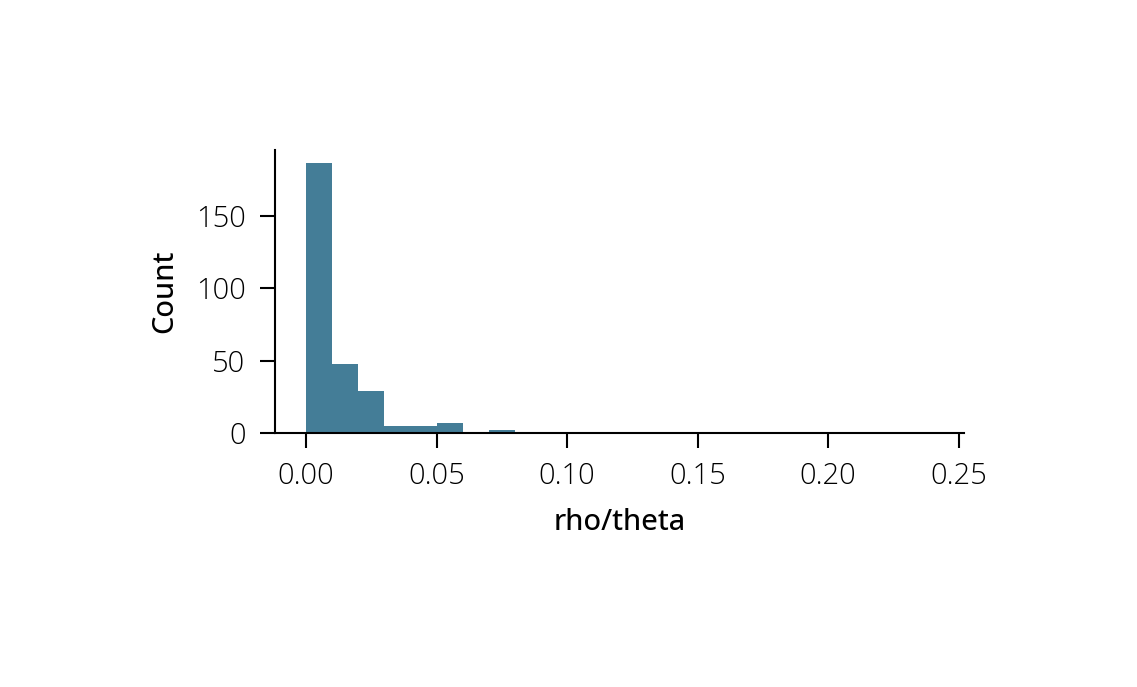

In [701]:
plt.figure(figsize=(3, 1.5))
sns.histplot(GCE_BranchStats_V2_DF["rho/theta"], bins = np.arange(0, 0.25, 0.01))
sns.despine()
plt.show()

In [702]:
GCE_BranchStats_V2_DF.head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
0,N0072,328,292,36,4,2,lineage1,295.04892,0.0,0.013699,0.006849,0.013699,0.123288,13.69863,6.849315,1.369863,6.849315,3.424658,0.684932,0.835647,0.123288


In [703]:
4 / 292

0.0136986301369863

In [704]:
#GCE_BranchStats_V2_DF["N_Mapped_GCE"].sum() / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"].sum()

In [705]:
GCE_BranchStats_V2_DF["N_Putative_GCE"].sum() / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"].sum()

0.013733468972533061

In [706]:
GCE_BranchStats_V2_DF["N_SNPs_InRecomb"].sum() / GCE_BranchStats_V2_DF["N_SNPs_NonRecomb"].sum()

0.12360122075279756

In [707]:
#G_BranchStats_DF["Number of Recombination Blocks"] / G_BranchStats_DF["Number of SNPs Outside Recombinations"]

### Brainstorming a simple model

Question: Are there branches which have accumulated more recombination events than expected by chance?

Facts:
1) The overall rate of recombination events detected per non-recombined SNP is `0.01365`


Approach #1: Assume poisson distribution



In [708]:
GCE_BranchStats_V2_DF.shape

(300, 21)

In [709]:
GCE_BranchStats_V2_DF.sort_values("rho/theta", ascending = False).head(4)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
159,Node_9,29,5,24,1,1,lineage4,6.046785,4.0,0.200000,0.200000,0.200000,4.800000,200.000000,100.000000,20.000000,200.000000,100.000000,20.000000,2.301030,4.800000
91,R25048,16,11,5,1,0,lineage2,11.075109,0.0,0.090909,0.000000,0.090909,0.454545,90.909091,45.454545,9.090909,0.000000,0.000000,0.000000,0.000000,0.454545
139,mada_1-50,60,26,34,2,2,lineage4,26.194555,0.0,0.076923,0.076923,0.076923,1.307692,76.923077,38.461538,7.692308,76.923077,38.461538,7.692308,1.886057,1.307692
238,Node_88,18,14,4,1,0,lineage2,11.067574,3.0,0.071429,0.000000,0.071429,0.285714,71.428571,35.714286,7.142857,0.000000,0.000000,0.000000,0.000000,0.285714


In [710]:
GCE_BranchStats_V2_DF.sort_values("rho/theta", ascending = False).tail(4)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
229,Node_79,0,0,0,0,0,lineage2,0.021911,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
240,Node_90,0,0,0,0,0,lineage2,0.021911,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
250,Node_100,0,0,0,0,0,lineage2,0.021911,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
275,Node_125,0,0,0,0,0,lineage2,0.021911,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


# Calc p-values for enrichment of events

In [711]:
def calc_Poisson_Test_Events_Enrich(Num_Obs_Events, Num_Outside_SNPs, mean_Rate):
    
    p_val = 1 - poisson.cdf(k = Num_Obs_Events, mu = mean_Rate * Num_Outside_SNPs )
    
    return p_val

def calc_Poisson_Test_Events_UnderEnrich(Num_Obs_Events, Num_Outside_SNPs, mean_Rate):
    
    p_val = poisson.cdf(k = Num_Obs_Events, mu = mean_Rate * Num_Outside_SNPs )
    
    return p_val


from scipy.stats import poisson

def calc_Poisson_Test_TwoSided(Num_Obs_Events, Num_Outside_SNPs, mean_Rate):
    """Computes a two-sided Poisson test p-value"""
    
    # Expected count under Poisson model
    expected_count = mean_Rate * Num_Outside_SNPs
    
    # Compute one-tailed p-values
    p_val_high = 1 - poisson.cdf(k = Num_Obs_Events - 1, mu = expected_count)  # P(X ≥ k)
    p_val_low = poisson.cdf(k = Num_Obs_Events, mu = expected_count)  # P(X ≤ k)
    
    # Two-sided p-value: Take the smaller of the two and double it
    two_sided_pval = 2 * min(p_val_high, p_val_low)
    
    # Ensure p-value does not exceed 1
    return min(two_sided_pval, 1)


In [712]:
GCE_BranchStats_V2_DF.head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
0,N0072,328,292,36,4,2,lineage1,295.04892,0.0,0.013699,0.006849,0.013699,0.123288,13.69863,6.849315,1.369863,6.849315,3.424658,0.684932,0.835647,0.123288


In [713]:
BranchStats_ByLin_DF


,N_Putative_GCE,N_Mapped_GCE,N_SNPs_NonRecomb,N_SNPs_InRecomb,EventsPerSNP,EventsPer100SNPs,GCE_SNP_Per_NonGCE_SNP
Lineage,,,,,,,
lineage1,63,34,4458,578,0.014132,1.413190,0.129655
lineage2,25,17,3018,221,0.008284,0.828363,0.073227
lineage3,20,12,1551,133,0.012895,1.289491,0.085751
lineage4,167,126,9775,1534,0.017084,1.708440,0.156931
lineage5,11,9,1257,93,0.008751,0.875099,0.073986
lineage6,12,6,1984,111,0.006048,0.604839,0.055948
lineage8,16,5,1076,172,0.014870,1.486989,0.159851


# Implement poission test BY LINEAGE

In [714]:
WGA_Mean_Rate = 0.0137 #0.01365 # 0.0136986301369863
# MappedGC_Mean_Rate = 0.0096 # 0.009579518480840963

print(WGA_Mean_Rate) 
#print(MappedGC_Mean_Rate) 


0.0137


In [715]:
BranchStats_ByLin_DF.columns

Index(['N_Putative_GCE', 'N_Mapped_GCE', 'N_SNPs_NonRecomb', 'N_SNPs_InRecomb', 'EventsPerSNP', 'EventsPer100SNPs', 'GCE_SNP_Per_NonGCE_SNP'], dtype='object')

In [716]:
#WGA_Mean_Rate = 0.01365# 0.0136986301369863

BranchStats_ByLin_DF["Enrich_Pval"] = BranchStats_ByLin_DF.apply(lambda row: calc_Poisson_Test_Events_Enrich(row["N_Putative_GCE"],
                                                                 row["N_SNPs_NonRecomb"],
                                                                 WGA_Mean_Rate), axis = 1 )

BranchStats_ByLin_DF["UnderEnrich_Pval"] = BranchStats_ByLin_DF.apply(lambda row: calc_Poisson_Test_Events_UnderEnrich(row["N_Putative_GCE"],
                                                                 row["N_SNPs_NonRecomb"],
                                                                 WGA_Mean_Rate), axis = 1 )

BranchStats_ByLin_DF['Enrich_Pval_fdr'] = fdrcorrection(BranchStats_ByLin_DF['Enrich_Pval'])[1]
BranchStats_ByLin_DF['UnderEnrich_Pval_fdr'] = fdrcorrection(BranchStats_ByLin_DF['UnderEnrich_Pval'])[1]

BranchStats_ByLin_DF["PutGC_TwoSided_Pval"] = BranchStats_ByLin_DF.apply(
    lambda row: calc_Poisson_Test_TwoSided(row["N_Putative_GCE"], row["N_SNPs_NonRecomb"], WGA_Mean_Rate), axis=1
)

BranchStats_ByLin_DF['PutGC_TwoSided_Pval_fdr'] = fdrcorrection(BranchStats_ByLin_DF['PutGC_TwoSided_Pval'])[1]

BranchStats_ByLin_DF['PutGC_TwoSided_Pval_Bonferonni'] = BranchStats_ByLin_DF['PutGC_TwoSided_Pval'] * 7

BranchStats_ByLin_DF["Lineage"] = BranchStats_ByLin_DF.index



# BranchStats_ByLin_DF["MapGC_Enrich_Pval"] = BranchStats_ByLin_DF.apply(lambda row: calc_Poisson_Test_Events_Enrich(row["N_Mapped_GCE"],
#                                                                  row["N_SNPs_NonRecomb"],
#                                                                  MappedGC_Mean_Rate), axis = 1 )

# BranchStats_ByLin_DF["MapGC_UnderEnrich_Pval"] = BranchStats_ByLin_DF.apply(lambda row: calc_Poisson_Test_Events_UnderEnrich(row["N_Mapped_GCE"],
#                                                                  row["N_SNPs_NonRecomb"],
#                                                                  MappedGC_Mean_Rate), axis = 1 )

# BranchStats_ByLin_DF['MapGC_Enrich_Pval_fdr'] = fdrcorrection(BranchStats_ByLin_DF['MapGC_Enrich_Pval'])[1]
# BranchStats_ByLin_DF['MapGC_UnderEnrich_Pval_fdr'] = fdrcorrection(BranchStats_ByLin_DF['MapGC_UnderEnrich_Pval'])[1]



# BranchStats_ByLin_DF["MapGC_TwoSided_Pval"] = BranchStats_ByLin_DF.apply(
#     lambda row: calc_Poisson_Test_TwoSided(row["N_Mapped_GCE"], row["N_SNPs_NonRecomb"], MappedGC_Mean_Rate), axis=1
# )

# BranchStats_ByLin_DF['MapGC_TwoSided_Pval_fdr'] = fdrcorrection(BranchStats_ByLin_DF['MapGC_TwoSided_Pval'])[1]






In [717]:
BranchStats_ByLin_DF

,N_Putative_GCE,N_Mapped_GCE,N_SNPs_NonRecomb,N_SNPs_InRecomb,EventsPerSNP,EventsPer100SNPs,GCE_SNP_Per_NonGCE_SNP,Enrich_Pval,UnderEnrich_Pval,Enrich_Pval_fdr,UnderEnrich_Pval_fdr,PutGC_TwoSided_Pval,PutGC_TwoSided_Pval_fdr,PutGC_TwoSided_Pval_Bonferonni,Lineage
Lineage,,,,,,,,,,,,,,,
lineage1,63,34,4458,578,0.014132,1.413190,0.129655,0.370867,0.629133,0.865357,0.803535,0.839155,0.899093,5.874087,lineage1
lineage2,25,17,3018,221,0.008284,0.828363,0.073227,0.995681,0.004319,0.999086,0.015117,0.008639,0.020157,0.060470,lineage2
lineage3,20,12,1551,133,0.012895,1.289491,0.085751,0.550454,0.449546,0.963294,0.786706,0.899093,0.899093,6.293648,lineage3
lineage4,167,126,9775,1534,0.017084,1.708440,0.156931,0.002510,0.997490,0.017572,0.997490,0.006420,0.020157,0.044943,lineage4
lineage5,11,9,1257,93,0.008751,0.875099,0.073986,0.922882,0.077118,0.999086,0.179942,0.154236,0.269912,1.079649,lineage5
lineage6,12,6,1984,111,0.006048,0.604839,0.055948,0.999086,0.000914,0.999086,0.006397,0.001828,0.012794,0.012794,lineage6
lineage8,16,5,1076,172,0.014870,1.486989,0.159851,0.311256,0.688744,0.865357,0.803535,0.810840,0.899093,5.675879,lineage8


In [718]:
BranchStats_ByLin_DF[["N_Mapped_GCE", "N_SNPs_NonRecomb", "EventsPerSNP", "PutGC_TwoSided_Pval", "PutGC_TwoSided_Pval_fdr"]]

,N_Mapped_GCE,N_SNPs_NonRecomb,EventsPerSNP,PutGC_TwoSided_Pval,PutGC_TwoSided_Pval_fdr
Lineage,,,,,
lineage1,34,4458,0.014132,0.839155,0.899093
lineage2,17,3018,0.008284,0.008639,0.020157
lineage3,12,1551,0.012895,0.899093,0.899093
lineage4,126,9775,0.017084,0.006420,0.020157
lineage5,9,1257,0.008751,0.154236,0.269912
lineage6,6,1984,0.006048,0.001828,0.012794
lineage8,5,1076,0.014870,0.810840,0.899093


In [719]:
BranchStats_ByLin_DF[["N_Putative_GCE", "N_SNPs_NonRecomb", "EventsPerSNP", "PutGC_TwoSided_Pval", "PutGC_TwoSided_Pval_fdr"]]

,N_Putative_GCE,N_SNPs_NonRecomb,EventsPerSNP,PutGC_TwoSided_Pval,PutGC_TwoSided_Pval_fdr
Lineage,,,,,
lineage1,63,4458,0.014132,0.839155,0.899093
lineage2,25,3018,0.008284,0.008639,0.020157
lineage3,20,1551,0.012895,0.899093,0.899093
lineage4,167,9775,0.017084,0.006420,0.020157
lineage5,11,1257,0.008751,0.154236,0.269912
lineage6,12,1984,0.006048,0.001828,0.012794
lineage8,16,1076,0.014870,0.810840,0.899093


In [720]:
BranchStats_ByLin_DF[["N_Putative_GCE", "N_SNPs_NonRecomb", "EventsPerSNP", "PutGC_TwoSided_Pval_fdr"]]

,N_Putative_GCE,N_SNPs_NonRecomb,EventsPerSNP,PutGC_TwoSided_Pval_fdr
Lineage,,,,
lineage1,63,4458,0.014132,0.899093
lineage2,25,3018,0.008284,0.020157
lineage3,20,1551,0.012895,0.899093
lineage4,167,9775,0.017084,0.020157
lineage5,11,1257,0.008751,0.269912
lineage6,12,1984,0.006048,0.012794
lineage8,16,1076,0.014870,0.899093


In [721]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')


In [722]:
BranchStats_ByLin_DF.head()

,N_Putative_GCE,N_Mapped_GCE,N_SNPs_NonRecomb,N_SNPs_InRecomb,EventsPerSNP,EventsPer100SNPs,GCE_SNP_Per_NonGCE_SNP,Enrich_Pval,UnderEnrich_Pval,Enrich_Pval_fdr,UnderEnrich_Pval_fdr,PutGC_TwoSided_Pval,PutGC_TwoSided_Pval_fdr,PutGC_TwoSided_Pval_Bonferonni,Lineage
Lineage,,,,,,,,,,,,,,,
lineage1,63,34,4458,578,0.014132,1.413190,0.129655,0.370867,0.629133,0.865357,0.803535,0.839155,0.899093,5.874087,lineage1
lineage2,25,17,3018,221,0.008284,0.828363,0.073227,0.995681,0.004319,0.999086,0.015117,0.008639,0.020157,0.060470,lineage2
lineage3,20,12,1551,133,0.012895,1.289491,0.085751,0.550454,0.449546,0.963294,0.786706,0.899093,0.899093,6.293648,lineage3
lineage4,167,126,9775,1534,0.017084,1.708440,0.156931,0.002510,0.997490,0.017572,0.997490,0.006420,0.020157,0.044943,lineage4
lineage5,11,9,1257,93,0.008751,0.875099,0.073986,0.922882,0.077118,0.999086,0.179942,0.154236,0.269912,1.079649,lineage5


In [723]:
Mtb_LinToColor_Dict

{'lineage1': '#DF83AC',
 'lineage2': '#7098CB',
 'lineage3': '#815D9F',
 'lineage4': '#E76956',
 'lineage5': '#B67548',
 'lineage6': '#6AB79E',
 'lineage8': '#E4515B',
 'Ancestral': 'black',
 'None': 'black'}

In [724]:
BranchStats_ByLin_Sorted_DF = BranchStats_ByLin_DF.sort_values("EventsPerSNP", ascending=False)
BranchStats_ByLin_Sorted_DF.shape

(7, 15)

In [725]:
BranchStats_ByLin_Sorted_DF[["N_Putative_GCE", "N_SNPs_NonRecomb", "EventsPerSNP", "PutGC_TwoSided_Pval_fdr"]]

,N_Putative_GCE,N_SNPs_NonRecomb,EventsPerSNP,PutGC_TwoSided_Pval_fdr
Lineage,,,,
lineage4,167,9775,0.017084,0.020157
lineage8,16,1076,0.014870,0.899093
lineage1,63,4458,0.014132,0.899093
lineage3,20,1551,0.012895,0.899093
lineage5,11,1257,0.008751,0.269912
lineage2,25,3018,0.008284,0.020157
lineage6,12,1984,0.006048,0.012794


In [726]:
!mkdir Fig5.GCE_PhyloDistr/

mkdir: cannot create directory ‘Fig5.GCE_PhyloDistr/’: File exists


/tmp/ipykernel_775283/4048480351.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


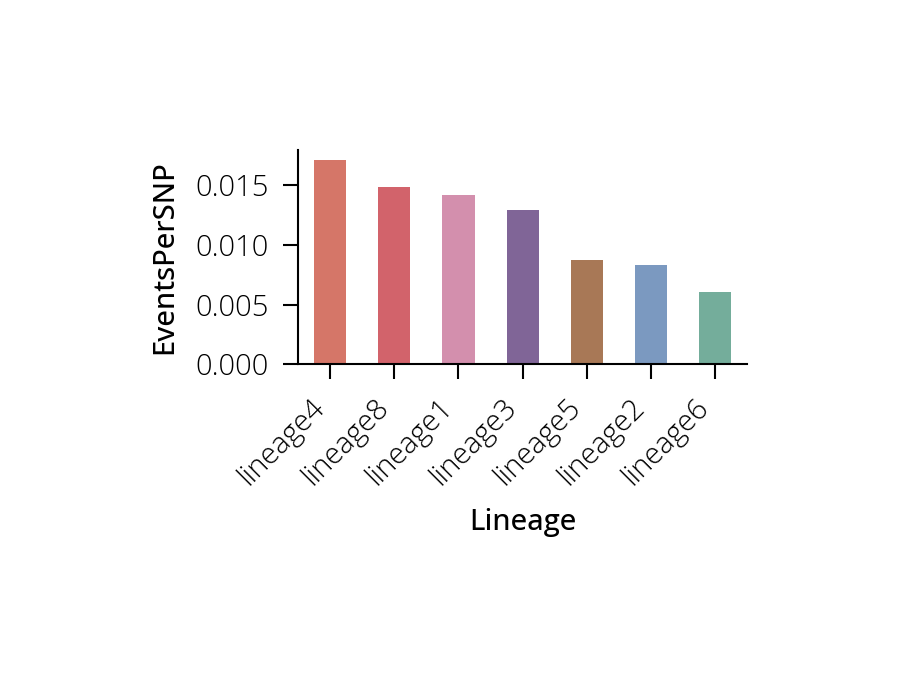

In [727]:
fig, ax1 = plt.subplots(1, 1, figsize=(2.2, 1.5))

sns.barplot(x = "Lineage",
            y = "EventsPerSNP", hue = "Lineage",
            palette = Mtb_LinToColor_Dict, width = 0.5,
            data = BranchStats_ByLin_Sorted_DF,
            ax = ax1)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_yticks([0.000, 0.005, 0.010, 0.015])

sns.despine()
#plt.savefig('dGCEFreq.PerLineage.Barplot.V2.svg')
plt.show()

In [728]:
print(WGA_Mean_Rate)

0.0137


/tmp/ipykernel_775283/775484480.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


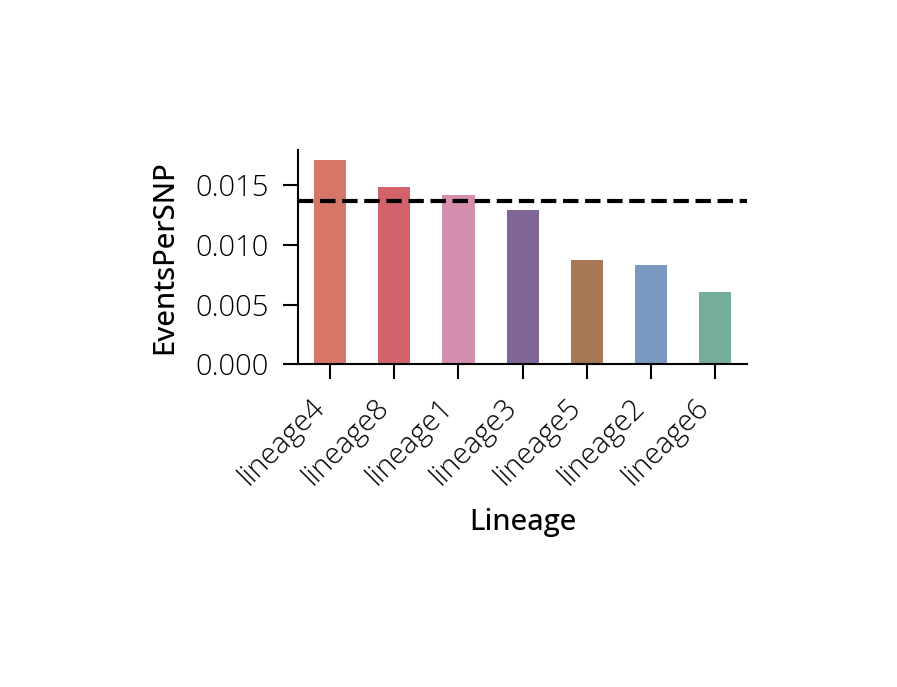

In [729]:
fig, ax1 = plt.subplots(1, 1, figsize=(2.2, 1.5))

sns.barplot(x = "Lineage",
            y = "EventsPerSNP", hue = "Lineage",
            palette = Mtb_LinToColor_Dict, width = 0.5,
            data = BranchStats_ByLin_Sorted_DF,
            ax = ax1)

# Add a dashed horizontal line at y = 0.0137
plt.axhline(y=WGA_Mean_Rate, color='black', linestyle='dashed', linewidth= 1)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_yticks([0.000, 0.005, 0.010, 0.015])

sns.despine()
plt.savefig('./Fig5.GCE_PhyloDistr/dGCEFreq.PerLineage.Barplot.WiMeanRateLine.V2.svg')
plt.show()

# Extras

In [730]:
# sns.barplot(x = "Lineage",
#             y = "MappedEventsPerSNP",
#             palette = LinToColor_Dict,
#             data = BranchStats_ByLin_DF)

# # Add a dashed horizontal line at y = 0.0096
# #plt.axhline(y=MappedGC_Mean_Rate, color='black', linestyle='dashed', linewidth=1.5)

# sns.despine()
# plt.show()

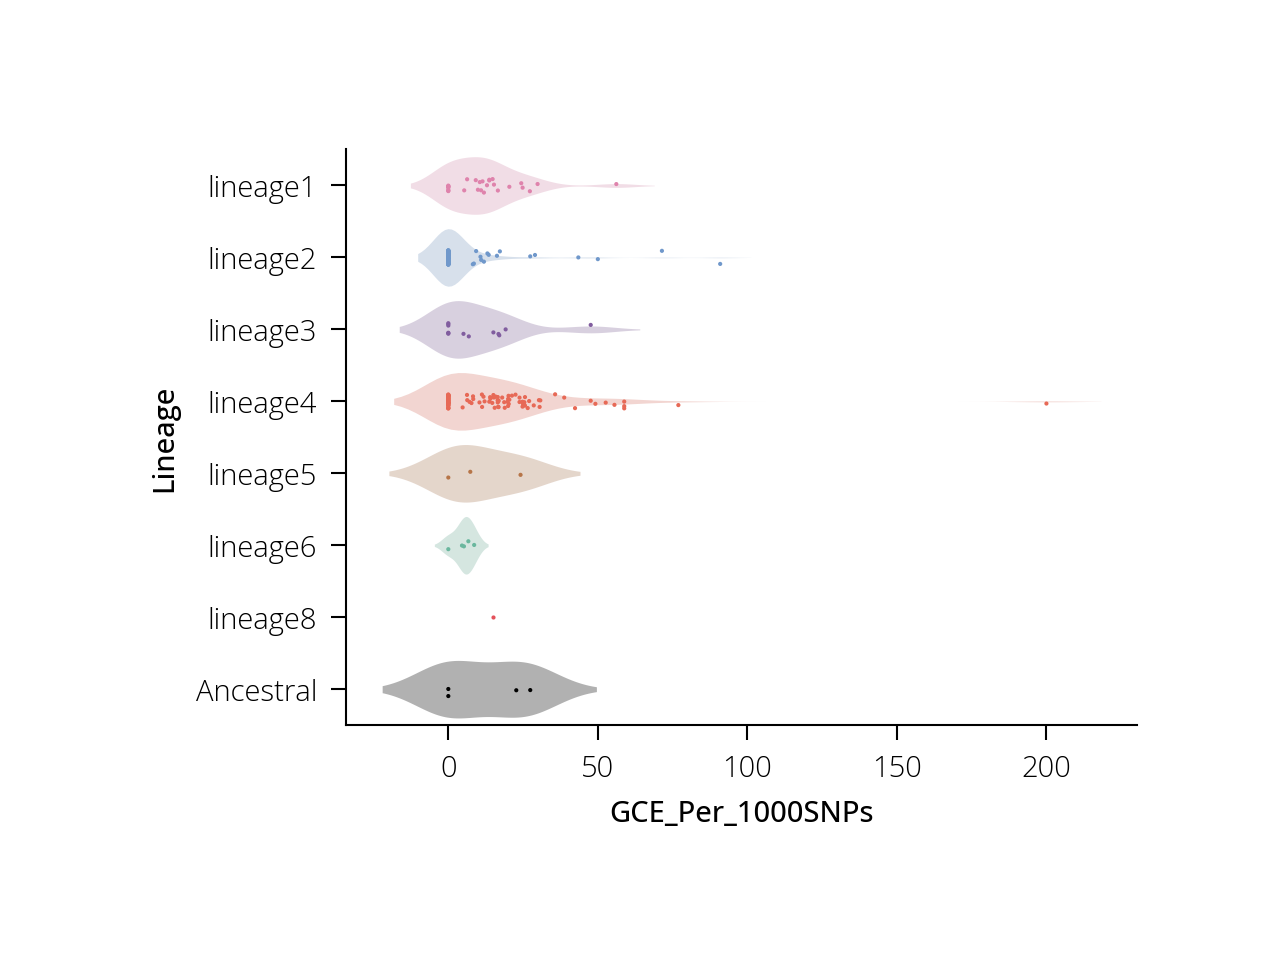

In [731]:
sns.stripplot(x = "GCE_Per_1000SNPs", y = "Lineage", hue = "Lineage",
              palette = Mtb_LinToColor_Dict, s = 1, edgecolor = "black",
               data = GCE_BranchStats_V2_DF)

sns.violinplot(x = "GCE_Per_1000SNPs", y = "Lineage", hue = "Lineage",
              palette = Mtb_LinToColor_Dict, alpha = 0.3,
               data = GCE_BranchStats_V2_DF)
sns.despine()
plt.show()

# Test calculations for poisson model of GCE frequency

### What is the probablity of observing at least 1 event after 5 SNPs?

In [732]:

Mean_Rate = 0.013733468972533061

Num_Outside_SNPs = 5
Num_Obs_Events = 1

#calculate probability
1 - poisson.cdf(k = Num_Obs_Events, mu = Mean_Rate * Num_Outside_SNPs )


0.002252404246825379

In [733]:
0.0022257238532229495 * 9

0.020031514679006546

In [734]:
0.0022257238532229495 * 315

0.7011030137652291

### What is the probablity of observing at least 2 events after 60 SNPs?

In [735]:
Num_Outside_SNPs = 60
Num_Obs_Events = 10

#calculate probability
1 - poisson.cdf(k = Num_Obs_Events, mu = Mean_Rate * Num_Outside_SNPs )


1.4026394490329608e-09

# Dev Code to highlight specific branch(es) of the phylogeny

In [755]:
#def plotRecombOnPhylo(i_ParentNode_Name, i_ChildNode_Name, input_Tree):
def highlight_TargetNodes_V1(targetNodes, input_Tree, i_LinToColor_Dict):

    input_Tree_Labeled = input_Tree.copy()
        
    # Draws nodes as small red spheres of diameter equal to 10 pixels
    i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
    #i_nstyle["shape"] = "sphere"
    i_nstyle["size"] = 0.3
    i_nstyle["fgcolor"] = "purple" #hex_color #"red"
    i_nstyle["vt_line_color"] = "purple"
    i_nstyle["hz_line_color"] = "purple"
    i_nstyle["hz_line_width"] = 1

    for n in input_Tree_Labeled.traverse():

        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(n.name, "None")
        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        nstyle["size"] = 0
        nstyle["fgcolor"] = "black"

        nstyle["vt_line_color"] = i_LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = i_LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_color"] = "black"
        nstyle["hz_line_color"] = "black"
        nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
        nstyle["hz_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            
        if n.is_leaf():
            nstyle["size"] = 0
        
        if n.name in targetNodes:
            nstyle["size"] = 0
            #nstyle["fgcolor"] = "red" #hex_color #"red"
            #nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            nstyle["vt_line_color"] = "purple"
            nstyle["hz_line_color"] = "purple"
            nstyle["hz_line_width"] = 1
            
        n.set_style(nstyle)

    return input_Tree_Labeled


def highlight_TargetNodes_V2(targetNodes, input_Tree):

    input_Tree_Labeled = input_Tree.copy()
        
    # Draws nodes as small red spheres of diameter equal to 10 pixels
    i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
    #i_nstyle["shape"] = "sphere"
    #i_nstyle["size"] = 0
    #i_nstyle["fgcolor"] = "purple" #hex_color #"red"
    #i_nstyle["vt_line_color"] = "purple"
    #i_nstyle["hz_line_color"] = "purple"
    #i_nstyle["hz_line_width"] = 1

    for n in input_Tree_Labeled.traverse():

        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(n.name, "None")
        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        nstyle["size"] = 0
        nstyle["fgcolor"] = "black"

        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_color"] = "black"
        nstyle["hz_line_color"] = "black"
        nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
        nstyle["hz_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            
        if n.is_leaf():
            nstyle["size"] = 0
        
        if n.name in targetNodes:
            print(n.name, "found. We will style this node differently.")
            #nstyle["fgcolor"] = "red" #hex_color #"red"

            nstyle["shape"] = "sphere"
            nstyle["size"] = 3
            nstyle["fgcolor"] = "darkred" #"darkred"
            nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            nstyle["vt_line_color"] = "darkred"
            nstyle["hz_line_color"] = "darkred"
            nstyle["hz_line_width"] = 1
            n.set_style(nstyle)

        else:
            n.set_style(nstyle)
            n.img_style["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
            n.img_style["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")

        n.set_style(nstyle)

    return input_Tree_Labeled




# Figure out the ancestral branch for each lineage

In [743]:
GCE_BranchStats_V2_DF.query("Lineage == 'lineage1' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
297,Node_147,608,543,65,9,5,lineage1,556.299683,15.0,0.016575,0.009208,0.016575,0.119705,16.574586,8.287293,1.657459,9.208103,4.604052,0.92081,0.96417,0.119705


In [745]:
GCE_BranchStats_V2_DF.query("Lineage == 'lineage2' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
281,Node_131,351,306,45,4,3,lineage2,314.938965,61.0,0.013072,0.009804,0.013072,0.147059,13.071895,6.535948,1.30719,9.803922,4.901961,0.980392,0.9914,0.147059


In [746]:
GCE_BranchStats_V2_DF.query("Lineage == 'lineage3' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
221,Node_71,345,313,32,6,4,lineage3,321.303497,7.0,0.019169,0.01278,0.019169,0.102236,19.169329,9.584665,1.916933,12.779553,6.389776,1.277955,1.106516,0.102236


In [747]:
GCE_BranchStats_V2_DF.query("Lineage == 'lineage4' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
215,Node_65,208,192,16,2,1,lineage4,199.414017,62.0,0.010417,0.005208,0.010417,0.083333,10.416667,5.208333,1.041667,5.208333,2.604167,0.520833,0.716699,0.083333


In [748]:
GCE_BranchStats_V2_DF.query("Lineage == 'lineage5' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
151,Node_1,882,816,66,6,4,lineage5,827.408081,2.0,0.007353,0.004902,0.007353,0.080882,7.352941,3.676471,0.735294,4.901961,2.45098,0.490196,0.69037,0.080882


In [749]:
GCE_BranchStats_V2_DF.query("Lineage == 'lineage6' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
153,Node_3,787,746,41,5,2,lineage6,751.77594,3.0,0.006702,0.002681,0.006702,0.05496,6.702413,3.351206,0.670241,2.680965,1.340483,0.268097,0.428291,0.05496


In [750]:
GCE_BranchStats_V2_DF.query("Lineage == 'lineage8' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
47,RW-TB008,1248,1076,172,16,5,lineage8,1147.000244,0.0,0.01487,0.004647,0.01487,0.159851,14.869888,7.434944,1.486989,4.64684,2.32342,0.464684,0.667158,0.159851


# Examine lineage specific events

In [799]:
LinAncBranches = ["Node_147", # L1
                  "Node_131", # L2
                  "Node_71",  # L3
                  "Node_65",  # L4
                  "Node_1",   # L5
                  "Node_3",   # L6
                  "RW-TB008"] # L8

LinAncBranches_L1to6 = ["Node_147", # L1
                  "Node_131", # L2
                  "Node_71",  # L3
                  "Node_65",  # L4
                  "Node_1",   # L5
                  "Node_3",   # L6
                  ]


In [740]:
5 + 3 + 4 + 1 + 4 + 2 +5

24

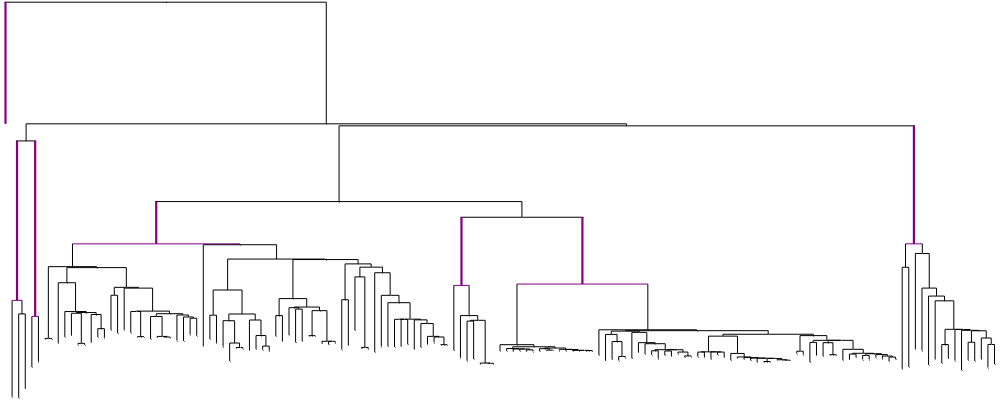

In [758]:

Tree_LinAncNodes_Labeled_1 = highlight_TargetNodes_V1(LinAncBranches, i_Gubbins_T, Mtb_LinToColor_Dict) 
Tree_LinAncNodes_Labeled_1.render("%%inline", w = 1000, tree_style = ts_vt_NoScale)


In [762]:
LinAncBranches

['Node_147', 'Node_131', 'Node_71', 'Node_65', 'Node_1', 'Node_3', 'RW-TB008']

In [763]:
GCE_ABM_OnAncLinBranches_DF = GCE_ABM_DF[GCE_ABM_DF["Child_Node"].isin(LinAncBranches)].sort_values(["Lineage", "Overlap_Gene_RvIDs"])

In [764]:
GCE_ABM_OnAncLinBranches_DF.shape

(48, 47)

In [801]:
GCE_ABM_AncL1to6_Branches_DF = GCE_ABM_DF[GCE_ABM_DF["Child_Node"].isin(LinAncBranches_L1to6)].sort_values(["Lineage", "Overlap_Gene_RvIDs"])
GCE_ABM_AncL1to6_Branches_DF.shape

(32, 47)

In [765]:
GCE_ABM_OnAncLinBranches_DF.groupby("Lineage")["Overlap_Genes"].count()

Lineage
lineage1     9
lineage2     4
lineage3     6
lineage4     2
lineage5     6
lineage6     5
lineage8    16
Name: Overlap_Genes, dtype: int64

In [767]:
GCE_ABM_OnAncLinBranches_DF.groupby("Lineage")["Overlap_Genes"].count().sum()

48

In [768]:
GCE_ABM_OnAncLinBranches_DF[["Lineage", "Overlap_Genes"]].value_counts()

Lineage   Overlap_Genes  
lineage8  PE_PGRS21          2
lineage1  PE_PGRS27          1
          PE_PGRS18          1
          PPE55              1
          PPE59              1
          PPE60              1
          PPE54              1
          Rv2828c            1
          _                  1
lineage2  PE_PGRS27          1
          PPE59              1
          Rv0095c            1
          lppA,lppB          1
lineage3  PE_PGRS28          1
lineage1  Rv0094c            1
lineage3  PPE55              1
          Rv2828c            1
          esxL               1
          _                  1
lineage4  PE_PGRS27          1
          PPE55              1
lineage5  PE_PGRS6           1
lineage3  ppsA               1
lineage5  PPE56              1
          Rv0094c,Rv0095c    1
          Rv1945             1
          Rv2082             1
lineage6  PE_PGRS10          1
          PE_PGRS27          1
          PPE54              1
lineage5  PPE54              1
lineage6  Rv0

In [778]:
GCE_ABM_OnAncLinBranches_DF[["Overlap_Genes"]].value_counts()

Overlap_Genes  
PE_PGRS27          5
PPE54              3
PPE55              3
_                  3
PE_PGRS28          2
PPE56              2
Rv1945             2
Rv2082             2
Rv2828c            2
Rv0094c            2
Rv0094c,Rv0095c    2
PPE59              2
PE_PGRS21          2
PPE18,esxK,esxL    1
PE_PGRS54          1
PE_PGRS58          1
PE_PGRS6           1
PE_PGRS44          1
PE_PGRS18          1
PE_PGRS10          1
PPE60              1
Rv1148c            1
Rv0829             1
Rv0397             1
Rv0095c            1
esxL               1
esxO,esxP          1
lppA,lppB          1
ppsA               1
Name: count, dtype: int64

In [779]:
GCE_ABM_OnAncLinBranches_DF[["Overlap_Genes"]].value_counts().shape

(29,)

In [802]:
GCE_ABM_AncL1to6_Branches_DF[["Overlap_Genes"]].value_counts()

Overlap_Genes  
PE_PGRS27          4
PPE55              3
PPE54              3
Rv0094c            2
PPE59              2
_                  2
Rv2828c            2
PE_PGRS18          1
PE_PGRS10          1
PE_PGRS6           1
PE_PGRS28          1
PPE56              1
PPE60              1
Rv0095c            1
Rv0094c,Rv0095c    1
Rv1945             1
Rv0397             1
Rv2082             1
esxL               1
lppA,lppB          1
ppsA               1
Name: count, dtype: int64

In [ ]:
PE_PGRS27          5
PPE54              3
PPE55              3
_                  3
PE_PGRS28          2
PPE56              2
Rv1945             2
Rv2082             2
Rv2828c            2
Rv0094c            2
Rv0094c,Rv0095c    2
PPE59              2
PE_PGRS21          2
PPE18,esxK,esxL    1
PE_PGRS54          1
PE_PGRS58          1
PE_PGRS6           1
PE_PGRS44          1
PE_PGRS18          1
PE_PGRS10          1
PPE60              1
Rv1148c            1
Rv0829             1
Rv0397             1
Rv0095c            1
esxL               1
esxO,esxP          1
lppA,lppB          1
ppsA               1

In [780]:
GCE_ABM_OnAncLinBranches_DF.head(3)

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
12,NC_000962.3,103893,104034,.,Node_148,Node_147,2463.174204,6,"[R27252, R23887, N0153, N0072, mada_1-10, mada...",103892,103963.0,142,lineage1,15,Rv0094c,Rv0094c,Event_013,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,15,False,0.000000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,56,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,False,2
75,NC_000962.3,1095981,1096567,.,Node_148,Node_147,2414.268739,7,"[R27252, R23887, N0153, N0072, mada_1-10, mada...",1095980,1096273.5,587,lineage1,15,PE_PGRS18,Rv0980c,Event_076,False,True,False,False,PR_HmRegion_041,2,1,0,0,1,1,1,1,15,False,0.142857,2,1,PE_PGRS17-H37Rv-1093366-1094592,PE_PGRS17,0.8103,2294.5,58,1,PE_PGRS17-H37Rv-1093366-1094592,PE_PGRS17,1.0000,2294.5,True,2
123,NC_000962.3,1633973,1634539,.,Node_148,Node_147,2441.487166,7,"[R27252, R23887, N0153, N0072, mada_1-10, mada...",1633972,1634255.5,567,lineage1,15,PE_PGRS27,Rv1450c,Event_124,False,True,False,False,PR_HmRegion_064,2,1,0,0,2,1,1,1,15,False,0.142857,2,1,PE_PGRS9-H37Rv-835775-836519,PE_PGRS9,0.1207,798108.5,58,1,PE_PGRS9-H37Rv-835775-836519,PE_PGRS9,0.2857,798108.5,False,1


### L1

In [769]:
GCE_BranchStats_V2_DF.sort_values("Num_Tips_Downstream", ascending=False).query("Lineage == 'lineage1'").head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,GCE_Per_1000SNPs,GCE_Per_500SNPs,GCE_Per_100SNPs,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,GCE_SNP_Per_NonGCE_SNP
297,Node_147,608,543,65,9,5,lineage1,556.299683,15.0,0.016575,0.009208,0.016575,0.119705,16.574586,8.287293,1.657459,9.208103,4.604052,0.92081,0.96417,0.119705


In [797]:
GCE_ABM_OnAncLinBranches_DF.query("Lineage == 'lineage1'")[["EventID", "Overlap_Genes", "snp_count", "MappedEvent"]]

,EventID,Overlap_Genes,snp_count,MappedEvent
12,Event_013,Rv0094c,6,False
75,Event_076,PE_PGRS18,7,True
123,Event_124,PE_PGRS27,7,False
228,Event_229,Rv2828c,14,False
245,Event_246,PPE54,6,True
253,Event_254,PPE55,11,True
271,Event_272,PPE59,5,True
296,Event_297,PPE60,5,True
238,Event_239,_,4,False


### L2

In [485]:
GCE_BranchStats_V2_DF.sort_values("Num_Tips_Downstream", ascending=False).query("Lineage == 'lineage2'").head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,BranchLenToAncNode
281,Node_131,351,306,45,4,3,lineage2,314.938965,61.0,0.013072,0.009804,0.013072,0.147059,9.803922,4.901961,0.980392,0.9914,1329.000212


In [795]:
GCE_ABM_OnAncLinBranches_DF.query("Lineage == 'lineage2'")[["EventID", "Overlap_Genes", "snp_count", "MappedEvent"]]

,EventID,Overlap_Genes,snp_count,MappedEvent
22,Event_023,Rv0095c,25,True
131,Event_132,PE_PGRS27,5,True
219,Event_220,"lppA,lppB",10,False
269,Event_270,PPE59,5,True


### L3

In [489]:
GCE_BranchStats_V2_DF.sort_values("Num_Tips_Downstream", ascending=False).query("Lineage == 'lineage3'").head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,BranchLenToAncNode
221,Node_71,345,313,32,6,4,lineage3,321.303497,7.0,0.019169,0.01278,0.019169,0.102236,12.779553,6.389776,1.277955,1.106516,1335.364744


In [793]:
GCE_ABM_OnAncLinBranches_DF.query("Lineage == 'lineage3'")[["EventID", "Overlap_Genes", "snp_count", "MappedEvent"]]

,EventID,Overlap_Genes,snp_count,MappedEvent
104,Event_105,esxL,5,True
151,Event_152,PE_PGRS28,5,True
229,Event_230,Rv2828c,8,True
235,Event_236,ppsA,5,False
259,Event_260,PPE55,5,True
224,Event_225,_,4,False


### L4

In [493]:
GCE_BranchStats_V2_DF.sort_values("Num_Tips_Downstream", ascending=False).query("Lineage == 'lineage4'").head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,BranchLenToAncNode
215,Node_65,208,192,16,2,1,lineage4,199.414017,62.0,0.010417,0.005208,0.010417,0.083333,5.208333,2.604167,0.520833,0.716699,1139.47251


In [792]:
GCE_ABM_OnAncLinBranches_DF.query("Lineage == 'lineage4'")[["EventID", "Overlap_Genes", "snp_count", "MappedEvent"]]

,EventID,Overlap_Genes,snp_count,MappedEvent
124,Event_125,PE_PGRS27,4,False
255,Event_256,PPE55,12,True


### L5

In [497]:
GCE_BranchStats_V2_DF.sort_values("Num_Tips_Downstream", ascending=False).query("Lineage == 'lineage5'").head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,BranchLenToAncNode
151,Node_1,882,816,66,6,4,lineage5,827.408081,2.0,0.007353,0.004902,0.007353,0.080882,4.901961,2.45098,0.490196,0.69037,1481.555197


In [791]:
GCE_ABM_OnAncLinBranches_DF.query("Lineage == 'lineage5'")[["EventID", "Overlap_Genes", "snp_count", "MappedEvent"]]

,EventID,Overlap_Genes,snp_count,MappedEvent
9,Event_010,"Rv0094c,Rv0095c",31,True
52,Event_053,PE_PGRS6,5,False
191,Event_192,Rv1945,14,True
203,Event_204,Rv2082,6,False
242,Event_243,PPE54,6,True
265,Event_266,PPE56,4,True


### L6

In [501]:
GCE_BranchStats_V2_DF.sort_values("Num_Tips_Downstream", ascending=False).query("Lineage == 'lineage6'").head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,BranchLenToAncNode
153,Node_3,787,746,41,5,2,lineage6,751.77594,3.0,0.006702,0.002681,0.006702,0.05496,2.680965,1.340483,0.268097,0.428291,1405.923056


In [790]:
GCE_ABM_OnAncLinBranches_DF.query("Lineage == 'lineage6'")[["EventID", "Overlap_Genes", "snp_count",  "MappedEvent"]]

,EventID,Overlap_Genes,snp_count,MappedEvent
4,Event_005,Rv0094c,7,False
49,Event_050,Rv0397,10,True
56,Event_057,PE_PGRS10,7,False
121,Event_122,PE_PGRS27,9,True
251,Event_252,PPE54,8,False


### L8

In [505]:
GCE_BranchStats_V2_DF.sort_values("Num_Tips_Downstream", ascending=False).query("Lineage == 'lineage8'").head(1)

,Node,Total_SNPs,N_SNPs_NonRecomb,N_SNPs_InRecomb,N_Putative_GCE,N_Mapped_GCE,Lineage,BranchLen,Num_Tips_Downstream,pGCE_Per_SNP,mGCE_Per_SNP,rho/theta,r/m,mGCE_Per_1000SNPs,mGCE_Per_500SNPs,mGCE_Per_100SNPs,Log2_mGCE_Per_1000SNPs,BranchLenToAncNode
47,RW-TB008,1248,1076,172,16,5,lineage8,1147.000244,0.0,0.01487,0.004647,0.01487,0.159851,4.64684,2.32342,0.464684,0.667158,573.500122


In [789]:
GCE_ABM_OnAncLinBranches_DF.query("Lineage == 'lineage8'")[["EventID", "Overlap_Genes", "snp_count", "MappedEvent"]]

,EventID,Overlap_Genes,snp_count,MappedEvent
6,Event_007,"Rv0094c,Rv0095c",16,False
63,Event_064,Rv0829,5,True
79,Event_080,PE_PGRS21,6,False
80,Event_081,PE_PGRS21,5,False
86,Event_087,Rv1148c,8,False
97,Event_098,"PPE18,esxK,esxL",10,False
122,Event_123,PE_PGRS27,18,True
139,Event_140,PE_PGRS28,6,False
187,Event_188,Rv1945,32,True
200,Event_201,Rv2082,7,False


In [509]:
GRE_ABM_DF[GRE_ABM_DF["Overlap_Genes"].str.contains("esxM")]

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,Lineage,CenterOfRegion,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,EventLen,IsTermNode,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Freq_SNP_FoundInAnyPR,MaxJC_ToAnyRvGene,GeneIDs_MaxJC,NGenesIDs_MaxJC,NUnqHashes_Event,N_SNPs_InAnyPRSeq,N_SNPs_InOnePRSeq
170,NC_000962.3,GUBBINS,CDS,2030487,2030521,0.0,.,Node_148,Node_133,1621.156987,4,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",2030486,NaN,2030503.5,esxM,Rv1792,True,False,False,False,Event_171,35,False,4,4,"esxK,esxL-H37Rv-1340643-1341288-esxI,esxJ-H37R...","esxK,esxL-esxI,esxJ-esxO,esxP-esxV,esxW",0.5417,NaN,24,1,"esxK,esxL-H37Rv-1340643-1341288","esxK,esxL",0.25,689538.0,0.0,1.0000,['esxM'],1.0,24.0,0.0,1.0
171,NC_000962.3,GUBBINS,CDS,2030518,2030765,0.0,.,Node_64,TB3251,2065.037007,7,['TB3251'],2030517,lineage4,2030641.0,"esxM,esxN","Rv1792,Rv1793",True,False,False,False,Event_172,248,True,4,1,"esxO,esxP-H37Rv-2625889-2626534","esxO,esxP",1.0000,595570.5,45,1,"esxK,esxL-H37Rv-1340643-1341288","esxK,esxL",1.00,689675.5,1.0,0.5556,"['esxP', 'esxK']",2.0,45.0,7.0,7.0
172,NC_000962.3,GUBBINS,CDS,2030604,2030848,0.0,.,Node_24,S0106-01,616.730224,6,['S0106-01'],2030603,lineage4,2030725.5,"esxM,esxN","Rv1792,Rv1793",True,False,False,False,Event_173,245,True,4,1,"esxK,esxL-H37Rv-1340643-1341288","esxK,esxL",0.8095,689760.0,42,1,"esxK,esxL-H37Rv-1340643-1341288","esxK,esxL",1.00,689760.0,1.0,0.5476,['esxL'],1.0,42.0,6.0,6.0
